In [2]:
# NumPy, Pandas, Matplotlib, Seaborn, Mini Projet

# etudiants.csv, filieres.csv | ventes.csv, produits.csv, magasins.csv

## Numpy 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from pathlib import Path

# réglages
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA = Path("data")

if not (DATA / "ventes.csv").exists():
  from generer_donnees import generer_tout
  generer_tout(DATA)

In [4]:
# plus rapidement !!! , vectorisé 

# liste python 

# - éléments de tous les types 
# - chaque élément est un objet éparpillé 
# - les boucles sont lentes 

# numpy
# - un seuil type 
# - bloc mémoire contigu


Liste Python :    46.1 ms
Numpy :     2.1 ms -> 21.608340x plus rapide


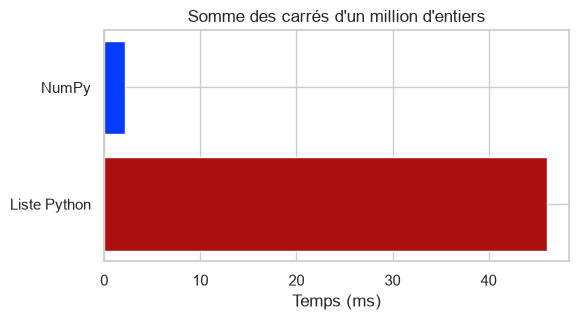

In [5]:
import time 

# somme des carrés d'un million d'entiers

n = 1_000_000
liste = list(range(n))
tableau = np.arange(n)


t0 = time.perf_counter(); s1 = sum(x ** 2 for x in liste); t_liste = time.perf_counter() - t0

t0 = time.perf_counter()
s2 =(tableau ** 2).sum()
t_numpy = time.perf_counter() - t0

print(f"Liste Python : {t_liste * 1000:7.1f} ms")
print(f"Numpy : {t_numpy * 1000:7.1f} ms -> {t_liste / t_numpy:0f}x plus rapide")

fig, ax = plt.subplots(figsize=(6,3))

ax.barh(["Liste Python", "NumPy"], [t_liste * 1000, t_numpy * 1000], color=["#AD1010", "#063BF9"])
ax.set_xlabel("Temps (ms)")
ax.set_title("Somme des carrés d'un million d'entiers")
plt.show()

In [6]:
# Tableau  --> lignes, colonnes 

# shape : les dimensions du tableau : (3, 4) ==> 3 lignes et 4 colonnes
# ndim : son nombre d'axes 
# size : son nombre d'éléments 
# dtype : le type des éléments 

## Fonctions

# np.array ==> np.array([1, 2, 3])
# np.zeros, np.ones, np.full ==> np.zeros((3, 4)) | np.full((3,4), None)
# np.arange  ==> np.arange(0, 100, 2) ==> [0, 2, 4, 6 ... ]
# np.linspace ==> 
# np.eye ==> np.eye(3)

In [7]:
a = np.array([12, 15, 9, 17])
M = np.array([[1,2,3],
              [4,5,6]])

for nom, t in [("a", a), ("M", M)]:
  print(f"{nom}: shape={t.shape}, ndim={t.ndim}, size={t.size}, dtype={t.dtype}")


print("\nzeros:\n", np.zeros((3, 4), dtype=int))
print("arange:", np.arange(0, 20, 5))
print("linspace:", np.linspace(0,1,5))
print("identité : \n", np.eye(3, dtype=int))

a: shape=(4,), ndim=1, size=4, dtype=int64
M: shape=(2, 3), ndim=2, size=6, dtype=int64

zeros:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
arange: [ 0  5 10 15]
linspace: [0.   0.25 0.5  0.75 1.  ]
identité : 
 [[1 0 0]
 [0 1 0]
 [0 0 1]]


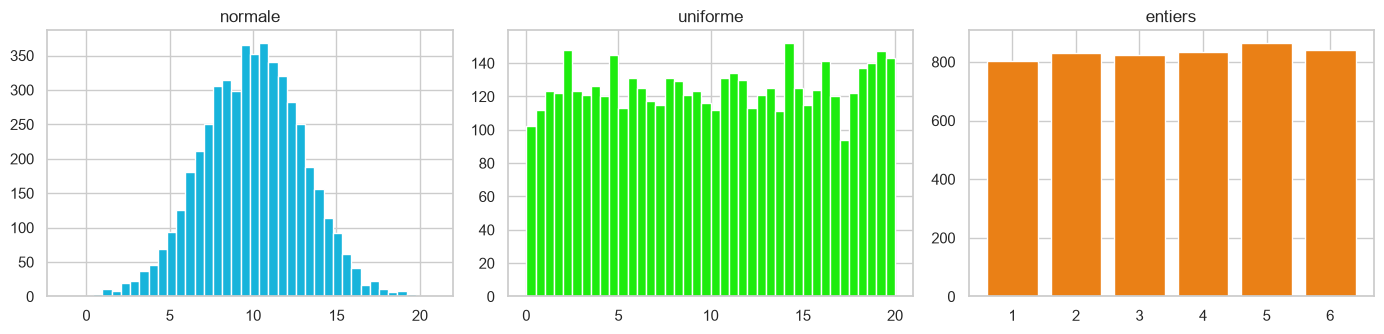

In [8]:
rng = np.random.default_rng(2026) # <-- graine, seed 

normale = rng.normal(loc=10, scale=3, size=5_000) 
uniforme = rng.uniform(low=0, high=20, size=5_000) 
entiers = rng.integers(1, 7, size=5_000) 

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(normale, bins=40, color="#17B4DB"); axes[0].set_title("normale")
axes[1].hist(uniforme, bins=40, color="#1DEC0E"); axes[1].set_title("uniforme")
axes[2].hist(entiers, bins=np.arange(0.5, 7.5), rwidth=0.8, color="#EA8016"); axes[2].set_title("entiers")
plt.tight_layout()
plt.show()

### Exercice 1.1 — Créer des tableaux

Les températures moyennes mensuelles (fictives) d'une ville côtière sont :
`[27.3, 28.1, 28.6, 28.2, 27.4, 26.1, 25.4, 25.3, 25.9, 26.8, 27.6, 27.4]`

1. Transformez cette liste en tableau `temp` et affichez `shape`, `ndim` et `dtype`.
2. Créez `mois`, les entiers de 1 à 12, avec `np.arange`.
3. Créez 7 valeurs régulièrement espacées entre 0 et 3 avec `np.linspace`.
4. Transformez `temp` en matrice 4 × 3 (un trimestre par ligne).
5. Avec un générateur de graine 0, simulez 1 000 notes suivant une loi normale de moyenne 11 et d'écart-type 3.

In [9]:
temp = np.array([27.3, 28.1, 28.6, 28.2, 27.4, 26.1, 25.4, 25.3, 25.9, 26.8, 27.6, 27.4])
print(temp.shape, temp.ndim, temp.dtype)

mois = np.arange(1, 13)
print(mois)

print(np.linspace(0, 3, 7))

# reshape 
trimestres = temp.reshape(4, 3)
print(trimestres)

rng0 = np.random.default_rng(0)
notes_sim = rng0.normal(11, 3, 1_000)
print(notes_sim[:5].round(2), " moyenne = ", notes_sim.mean().round(2))

(12,) 1 float64
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[0.  0.5 1.  1.5 2.  2.5 3. ]
[[27.3 28.1 28.6]
 [28.2 27.4 26.1]
 [25.4 25.3 25.9]
 [26.8 27.6 27.4]]
[11.38 10.6  12.92 11.31  9.39]  moyenne =  10.86


### Indexation, découpage et masque boolean 

In [10]:
# tableau [lignes, colonnes] <--> debut:fin:pas 

# Si X est le tableau

# X[0] ==> première ligne 
# X[:, 1] ==> deuxième colonne
# X[1:3, :2] ==> ligne 1, 2 colonne 0, 1
# X[[0, 4]] ==> lignes 0 et 4
# X[X > 10] ==> masque booléan
# np.where(cond, a, b) ==> a si la condition est vraie et b sinon


In [11]:
# matrice 8 étudiants et 4 matières

rng = np.random.default_rng(7)
notes = rng.integers(3, 20, size=(8, 4)).astype(float)
matières = np.array(["Python", "Stats", "Algèbre", "Anglais"])
print(notes)

print("\nÉtudiant n°0 :", notes[0])
print("Colonne Stats: ", notes[:, 1])
print("Etudiants 2 à 4, deux premières matières: \n", notes[2:5, :2])
print("Etudiants 0 et 7: \n", notes[[0, 7]])

# qui a eu au moins 12 en python 
masque = notes[:, 0] >= 12.
print("\n Masque : ", masque)
print("Lignes concernées : \n", notes[masque])
print("Nb de notes < 8 :", (notes < 8).sum())

plafonnees = np.where(notes > 18, 18, notes)
print(plafonnees)



[[19. 13. 14. 18.]
 [12. 16. 17.  6.]
 [ 3.  8.  7. 17.]
 [18.  3. 11. 16.]
 [ 5. 16.  5. 10.]
 [16.  8.  8.  7.]
 [15.  7. 19. 10.]
 [11. 11. 12. 12.]]

Étudiant n°0 : [19. 13. 14. 18.]
Colonne Stats:  [13. 16.  8.  3. 16.  8.  7. 11.]
Etudiants 2 à 4, deux premières matières: 
 [[ 3.  8.]
 [18.  3.]
 [ 5. 16.]]
Etudiants 0 et 7: 
 [[19. 13. 14. 18.]
 [11. 11. 12. 12.]]

 Masque :  [ True  True False  True False  True  True False]
Lignes concernées : 
 [[19. 13. 14. 18.]
 [12. 16. 17.  6.]
 [18.  3. 11. 16.]
 [16.  8.  8.  7.]
 [15.  7. 19. 10.]]
Nb de notes < 8 : 8
[[18. 13. 14. 18.]
 [12. 16. 17.  6.]
 [ 3.  8.  7. 17.]
 [18.  3. 11. 16.]
 [ 5. 16.  5. 10.]
 [16.  8.  8.  7.]
 [15.  7. 18. 10.]
 [11. 11. 12. 12.]]


In [12]:
# vue / copie 

x = np.arange(6) 
print("x d'origine :", x)
vue = x[:3]
vue[0] = 99
print("x après modification : ", x)

print("\n")

y = np.arange(6)
print("y d'origine :", y)
copie = y[:3].copy()
copie[0] = 99
print("y après modification de la copie: ", y)

x d'origine : [0 1 2 3 4 5]
x après modification :  [99  1  2  3  4  5]


y d'origine : [0 1 2 3 4 5]
y après modification de la copie:  [0 1 2 3 4 5]


### Exercice 1.2 — Indexer et filtrer

En utilisant la matrice `notes` ci-dessus :
1. Affichez les notes du **troisième** étudiant.
2. Affichez les notes d'**Algèbre** de tous les étudiants.
3. Quels étudiants (indices) ont **au moins 12 en Python ET au moins 10 en Stats** ? *(opérateur `&` et `np.flatnonzero`)*
4. Créez `notes_rattrapage` : toute note inférieure à 8 est remplacée par 8 (sans modifier `notes`).
5. Combien de notes sont comprises entre 10 et 15 inclus ?

In [13]:
rng = np.random.default_rng(7)
notes = rng.integers(3, 20, size=(8, 4)).astype(float)
matières = np.array(["Python", "Stats", "Algèbre", "Anglais"])

print(notes[2])
print(notes[:2])

cond = (notes[:, 0] >= 12) & (notes[:, 1] >= 10)
print("Indices :", np.flatnonzero(cond)) 

notes_rattrapage = np.where(notes < 8, 8, notes)
print(notes_rattrapage)

total = ((notes >= 10) & (notes <= 15)).sum()
print("Notes entre 10 et 15 inclus : ", total)

[ 3.  8.  7. 17.]
[[19. 13. 14. 18.]
 [12. 16. 17.  6.]]
Indices : [0 1]
[[19. 13. 14. 18.]
 [12. 16. 17.  8.]
 [ 8.  8.  8. 17.]
 [18.  8. 11. 16.]
 [ 8. 16.  8. 10.]
 [16.  8.  8.  8.]
 [15.  8. 19. 10.]
 [11. 11. 12. 12.]]
Notes entre 10 et 15 inclus :  11


### Vectorisation et broadcasting 

Prix en euros : [ 6.86  1.98  1.22  0.91 18.29]
Prix TTC (18%) : [ 5310.  1534.   944.   708. 14160.]
Racines : [ 67.1  36.1  28.3  24.5 109.5]


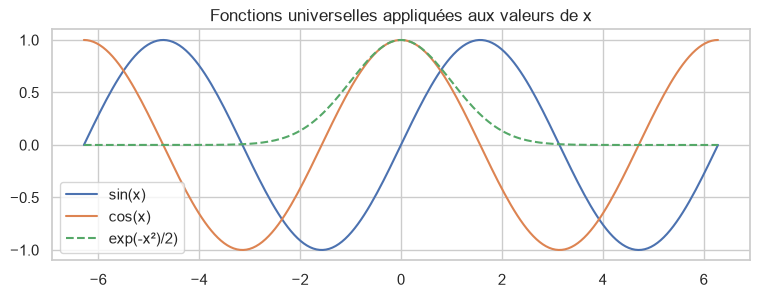

In [15]:
prix_fcfa = np.array([4500, 1300, 800, 600, 12000])

# 1€ = 655.957 fcfa 
print("Prix en euros :", (prix_fcfa / 655.957).round(2))
print("Prix TTC (18%) :", (prix_fcfa * 1.18))
print("Racines :", np.sqrt(prix_fcfa).round(1))

x = np.linspace(-2 * np.pi, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(x, np.sin(x), label="sin(x)")
ax.plot(x, np.cos(x), label="cos(x)")
ax.plot(x, np.exp(-x ** 2 / 2), label="exp(-x²)/2)", linestyle="--")
ax.legend()
ax.set_title("Fonctions universelles appliquées aux valeurs de x")
plt.show()

Moyennes pondérées : [16.12 13.5   7.   12.25  8.38 10.88 13.38 11.38]
Moyennes après standardisation :  [ 0. -0.  0.  0.]
Écarts-types après standardisation :  [1. 1. 1. 1.]


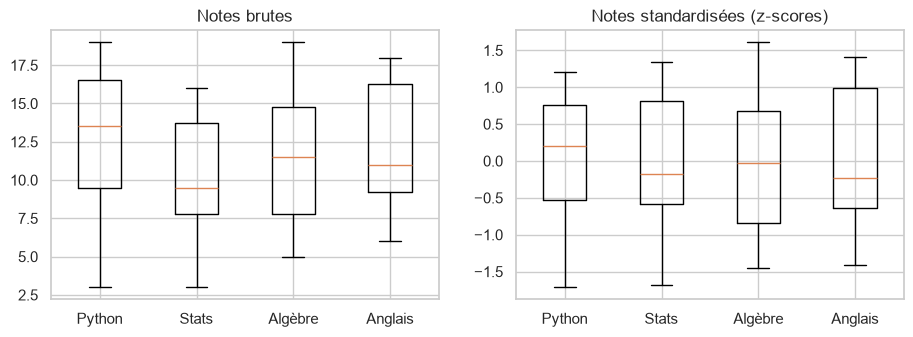

In [18]:
coefs = np.array([3, 2, 2, 1]) # 
ponderees = notes * coefs
moy_generale = ponderees.sum(axis=1) / coefs.sum()

print("Moyennes pondérées :", moy_generale.round(2))

# standardisation

Z = (notes - notes.mean(axis=0)) / notes.std(axis=0)
print("Moyennes après standardisation : ", Z.mean(axis=0).round(10))
print("Écarts-types après standardisation : ", Z.std(axis=0))

fig, axes = plt.subplots(1,2, figsize=(11, 3.5))

axes[0].boxplot(notes); axes[0].set_xticks(range(1,5), matières); axes[0].set_title("Notes brutes")
axes[1].boxplot(Z); axes[1].set_xticks(range(1,5), matières); axes[1].set_title("Notes standardisées (z-scores)")
plt.show()

###  Exercice 1.3 — Vectoriser 

Une chaîne possède 3 magasins et vend 4 produits. `stock` donne les quantités (magasins × produits) :
```python
stock = np.array([[120,  80, 45, 10],
                  [ 60, 150, 20,  5],
                  [ 90,  40, 70, 25]])
prix = np.array([4500, 1300, 800, 12000])     # prix unitaire de chaque produit (FCFA)
```
1. Calculez la **valeur du stock** de chaque produit dans chaque magasin (matrice 3 × 4), sans boucle.
2. Calculez la valeur totale du stock par magasin.
3. Chaque magasin applique une remise différente : `remise = np.array([0.05, 0.10, 0.0])`.
   Calculez la matrice des prix remisés (3 × 4). *Indice : il faut donner à `remise` la forme `(3, 1)` avec `remise[:, None]` ou `reshape`.*
4. Normalisez `stock` entre 0 et 1 (min-max) **colonne par colonne**.

In [23]:
stock = np.array([[120,  80, 45, 10],
                  [ 60, 150, 20,  5],
                  [ 90,  40, 70, 25]])
prix = np.array([4500, 1300, 800, 12000]) 

valeur = stock * prix 
print(valeur)
print("Par magasin : ", valeur.sum(axis=1))

remise = np.array([0.05, 0.10, 0.0])
prix_remises = prix * (1 - remise[:, None])
print(prix_remises)

mini, maxi = stock.min(axis=0), stock.max(axis=0)
print(((stock - mini) / (maxi - mini)).round(2))



[[540000 104000  36000 120000]
 [270000 195000  16000  60000]
 [405000  52000  56000 300000]]
Par magasin :  [800000 541000 813000]
[[ 4275.  1235.   760. 11400.]
 [ 4050.  1170.   720. 10800.]
 [ 4500.  1300.   800. 12000.]]
[[1.   0.36 0.5  0.25]
 [0.   1.   0.   0.  ]
 [0.5  0.   1.   1.  ]]


### Agrégations

In [ ]:
# sum, mean, median, std, min, max, argmin / argmax (position du min / max)
# axis = 0 --> on écrase les lignes -> 1 résultat par colonne 
# axis = 1 --> on écrase les colonnes --> un résultat par ligne 

# np.nanmean, np.nansum --> ignore np.nan values 

Moyenne globale : 11.56
Moyenne par matière (axis=0) : 
    Python 12.38
     Stats 10.25
   Algèbre 11.62
   Anglais 12.00
Moyenne par étudiant (axis=1): [16.   12.75  8.75 12.    9.    9.75 12.75 11.5 ]
Meilleur en Python : étudiant n° 0

mean avec NaN  nan  | nanmean :  12.0


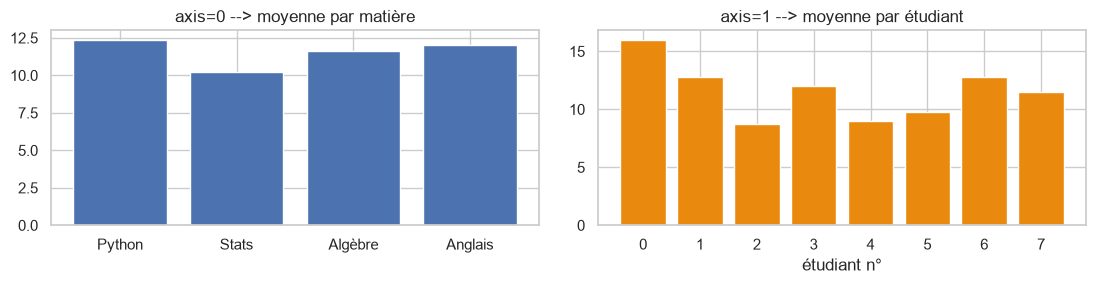

In [30]:
print("Moyenne globale :", notes.mean().round(2))
print("Moyenne par matière (axis=0) : ")
for m, moy in zip(matières, notes.mean(axis=0)):
  print(f"  {m:>8} {moy:.2f}")
print("Moyenne par étudiant (axis=1):", notes.mean(axis=1).round(2))
print("Meilleur en Python : étudiant n°", notes[:, 0].argmax())


avec_nan = np.array([12, np.nan, 15, 9])
print("\nmean avec NaN ", avec_nan.mean(), " | nanmean : ", np.nanmean(avec_nan))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].bar(matières, notes.mean(axis=0), color="#4C72B0")
axes[0].set_title("axis=0 --> moyenne par matière")
axes[1].bar(np.arange(len(notes)), notes.mean(axis=1), color= "#E98A0E")
axes[1].set_title("axis=1 --> moyenne par étudiant")
axes[1].set_xlabel("étudiant n°")
plt.tight_layout()
plt.show()  

### Exercice 1.4 — Agréger

Toujours avec `notes` et `coefs = [3, 2, 2, 1]` :
1. Quelle est la matière la plus difficile (moyenne la plus basse) ? Affichez son **nom**.
2. Quelle matière a les notes les plus dispersées (écart-type maximal) ?
3. Calculez la moyenne pondérée de chaque étudiant, puis le **pourcentage d'étudiants admis** (moyenne ≥ 10).

In [31]:
print("Plus difficile : ", matières[notes.mean(axis=0).argmin()])
print("Plus dispersée : ", matières[notes.std(axis=0).argmax()])

moy = (notes * coefs).sum(axis=1) / coefs.sum()
print("Moyennes pondérées : ", moy.round(2))
print("Taux d'admission : ", f"{(moy >= 10).mean():.0%}")

Plus difficile :  Stats
Plus dispersée :  Python
Moyennes pondérées :  [16.12 13.5   7.   12.25  8.38 10.88 13.38 11.38]
Taux d'admission :  75%


In [ ]:
# ndarray --> shape, ndim, dtype
# X [lignes, colonnes], masques X [X>0]
# Pas besoin de boucles ... utiliser vectorisation & broacasting 
# axis = 0 --> résultat par colonne | axis = 1 --> résultat par ligne 
# Graine | Seed 

## Pandas 

In [32]:
## Series : une colonne = des valeurs + un index (des étiquettes)
## DataFrame : un tableau = plusieurs Series qui partagent le même index. Chaque colonne ayant son propre type. 


## df.head(), df.shape() --> quelques lignes, dimensions 
## df.info() --> types et nombre de valeurs non nulles 
## df.describe() --> stats des colonnes numeriques (mean, std, etc ...)
## etc..

Samedi : 240  | total : 1032  | meilleur jour : Sam
Jours > 150:  ['Ven', 'Sam', 'Dim']


<Axes: title={'center': 'Pandas sait tracer 🐼 !'}>

/Users/ounzin/.pyenv/versions/orca/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 128060 (\N{PANDA FACE}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/ounzin/.pyenv/versions/orca/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128060 (\N{PANDA FACE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


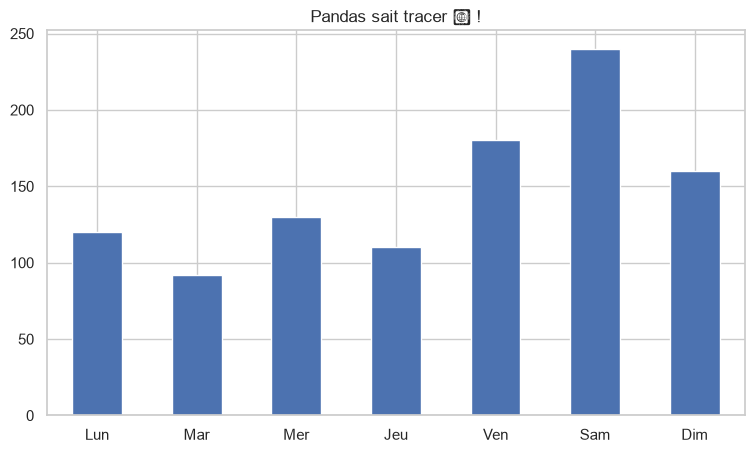

In [ ]:
ventes = pd.Series([120, 92, 130, 110, 180, 240, 160],
                   index=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"],
                   name="ventes")


print("Samedi :", ventes["Sam"], " | total :", ventes.sum(), " | meilleur jour :", ventes.idxmax())
print("Jours > 150: ", list(ventes[ventes > 150].index))

ventes.plot.bar(rot=0, color="#4c72b0", title="Pandas sait tracer 🐼 directement !")

In [47]:
# csv

etu_brut = pd.read_csv(DATA / "etudiants.csv")
print("Dimensions : ", etu_brut.shape)
etu_brut.head()

Dimensions :  (326, 11)


,id_etudiant,sexe,age,ville,filiere,heures_etude,taux_presence,note_python,note_stats,note_algebre,date_inscription
0,E001,M,24,Bohicon,Économie,7.30,80.00,7.80,10.80,5.40,2026-04-05
1,E002,M,26,porto-novo,Informatique,3.60,79.00,10.50,7.70,7.10,2026-04-03
2,E003,F,30,Cotonou,Physique,7.90,80.00,8.70,9.10,8.00,2026-04-03
3,E004,F,25,Abomey-Calavi,Économie,9.20,77.00,13.10,11.90,12.00,2026-03-18
4,E005,M,24,parakou,Maths,10.10,63.00,17.00,17.90,15.90,2026-04-07


In [48]:
etu_brut.info()

<class 'pandas.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_etudiant       326 non-null    str    
 1   sexe              326 non-null    str    
 2   age               326 non-null    int64  
 3   ville             326 non-null    str    
 4   filiere           326 non-null    str    
 5   heures_etude      316 non-null    float64
 6   taux_presence     326 non-null    float64
 7   note_python       326 non-null    float64
 8   note_stats        318 non-null    float64
 9   note_algebre      326 non-null    float64
 10  date_inscription  326 non-null    str    
dtypes: float64(5), int64(1), str(5)
memory usage: 28.1 KB


In [51]:
etu_brut.describe().T

,count,mean,std,min,25%,50%,75%,max
age,326.00,25.79,3.97,19.00,23.00,26.00,29.00,32.00
heures_etude,316.00,9.72,4.86,1.00,6.38,9.00,12.33,26.00
taux_presence,326.00,78.18,11.46,43.00,71.00,79.00,87.00,100.00
note_python,326.00,11.75,3.19,4.60,9.83,11.60,13.60,20.00
note_stats,318.00,11.43,3.04,2.80,9.10,11.30,13.40,19.70
note_algebre,326.00,12.25,3.27,4.00,9.90,12.30,14.67,20.00


In [55]:
print(etu_brut["filiere"].value_counts())
print(etu_brut["ville"].unique())

filiere
Informatique    114
Maths            90
Économie         81
Physique         41
Name: count, dtype: int64
<StringArray>
[       'Bohicon',    'porto-novo ',        'Cotonou',  'Abomey-Calavi',
       'parakou ',        'Parakou', 'abomey-calavi ',       'bohicon ',
        'BOHICON',  'ABOMEY-CALAVI',     'Porto-Novo',       'cotonou ',
        'COTONOU',     'PORTO-NOVO']
Length: 14, dtype: str


### Exercice 2.1 — Premier contact

1. Quel est l'âge médian ? La note de Python maximale ?
2. Quelles colonnes contiennent des valeurs manquantes ? *(indice : `isna().sum()`)*
3. Quel pourcentage des étudiants est en Informatique ? *(indice : `value_counts(normalize=True)`)*

In [57]:
print("Âge médian :", etu_brut["age"].median(), " | note Python max : ", etu_brut["note_python"].max())
manq = etu_brut.isna().sum()
print("Colonnes avec NaN", list(manq[manq > 0].index))
print(f"Informatique : {etu_brut['filiere'].value_counts(normalize=True)['Informatique']:.0%}")

Âge médian : 26.0  | note Python max :  20.0
Colonnes avec NaN ['heures_etude', 'note_stats']
Informatique : 35%


In [ ]:
# sélectionner et filtrer 

## df["col"] --> une colonne; df["col1", "col2"] --> plusieurs colonnes 
## df.loc[lignes, colonnes] par étiquettes (entendre index) (fin incluse) ; df.iloc[lignes, colonnes] par position (fin exclue)
## filtres --> masques et les opérateurs logiques 


In [72]:
print(etu_brut.iloc[0:3, 0:4 ], "\n")
print(etu_brut.loc[0:2, ["id_etudiant", "filiere"]])

  id_etudiant sexe  age        ville
0        E001    M   24      Bohicon
1        E002    M   26  porto-novo 
2        E003    F   30      Cotonou 

  id_etudiant       filiere
0        E001      Économie
1        E002  Informatique
2        E003      Physique


In [77]:
bons_info = etu_brut[(etu_brut['filiere'] == "Informatique") & (etu_brut["note_python"] >= 15)]
print("Informaticiens avec >= 15 en Python:", len(bons_info))

maths_phys = etu_brut[etu_brut['filiere'].isin(["Maths", "Physique"])]
print("Étudiants en Maths ou en Physique :", len(maths_phys))

etu_brut.sort_values("note_python", ascending=False).head()[["id_etudiant", "filiere", "note_python"]]

Informaticiens avec >= 15 en Python: 18
Étudiants en Maths ou en Physique : 131


,id_etudiant,filiere,note_python
163,E164,Maths,20.00
287,E288,Informatique,20.00
77,E078,Économie,20.00
93,E094,Informatique,20.00
117,E118,Économie,19.70


### Exercice 2.2 — Filtrer

1. Affichez les **étudiantes** (`sexe == "F"`) d'Économie ayant plus de 15 en Stats.
2. Les 5 étudiants qui étudient le plus (`nlargest`) : id, filière, heures, note de Python.
3. Combien d'étudiants ont un taux de présence **inférieur à 60 %** ou une note d'algèbre **inférieure à 5** ?

In [83]:
display(etu_brut[(etu_brut["sexe"] == "F") & (etu_brut["filiere"] == "Économie") & (etu_brut["note_stats"] > 15)])
display(etu_brut.nlargest(5, "heures_etude")[["id_etudiant", "filiere", "heures_etude", "note_python"]])

print(len(etu_brut[(etu_brut["taux_presence"] < 60) | (etu_brut["note_algebre"] < 5)]))

,id_etudiant,sexe,age,ville,filiere,heures_etude,taux_presence,note_python,note_stats,note_algebre,date_inscription
77,E078,F,32,Cotonou,Économie,18.80,86.00,20.00,16.10,11.40,2026-04-10
155,E156,F,24,Cotonou,Économie,21.30,56.00,17.10,19.70,14.90,2026-03-09
210,E211,F,29,Abomey-Calavi,Économie,11.80,70.00,12.60,15.10,15.40,2026-07-27


,id_etudiant,filiere,heures_etude,note_python
285,E286,Informatique,26.00,19.30
304,E305,Physique,25.90,19.40
130,E131,Maths,25.30,17.40
163,E164,Maths,24.50,20.00
55,E056,Économie,22.10,16.70


21


### Nettoyer les données 

Doublons :  6
heures_etude    10
note_stats       8
dtype: int64


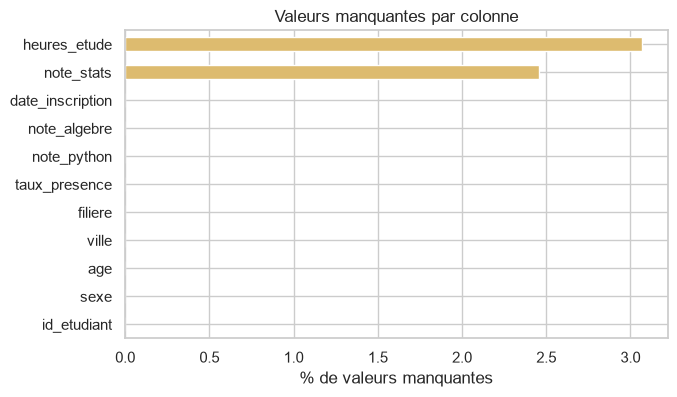

In [96]:
## Doublons, Valeurs manquantes, Texte incohérent, Mauvais types 

## Doublons ::: doublons --> duplicated().sum() --> drop_duplicates()
## Valeurs manquantes ::: isna().sum() --> dropna(), fillna(valeur)
## Texte incohérent ::: unique() --> .str.strip(), .str.title(), .replace({...})

print("Doublons : ", etu_brut.duplicated().sum())
manquants = etu_brut.isna().sum()
print(manquants[manquants > 0])

ax = (etu_brut.isna().mean() * 100).sort_values().plot.barh(color="#DDBB6F", figsize=(7,4))
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes par colonne")
plt.show()

In [114]:
etu = etu_brut.drop_duplicates().copy()

etu["ville"] = etu["ville"].str.strip().str.title() # "porto-novo" -> "Porto-Novo"
etu["date_inscription"] = pd.to_datetime(etu["date_inscription"], errors="coerce") # texte -> date
etu["heures_etude"] = etu["heures_etude"].fillna(etu["heures_etude"].median()) # imputation par la médiane 

etu = etu.reset_index(drop=True)
print("Villes : ", sorted(etu["ville"].unique()))
print("Dimensions : ", etu_brut.shape, "->", etu.shape)

Villes :  ['Abomey-Calavi', 'Bohicon', 'Cotonou', 'Parakou', 'Porto-Novo']
Dimensions :  (326, 11) -> (320, 11)


- calcul vectorisé entre colonnes : `df["c"] = df["a"] + df["b"]` ;
- `np.where(condition, si_vrai, si_faux)` pour une colonne conditionnelle ;
- `pd.cut` pour découper une variable numérique en tranches ;
- l'accesseur `.dt` pour les dates : `.dt.month`, `.dt.day_name()`…

In [116]:
colonnes_notes = ["note_python", "note_stats", "note_algebre"]
etu["moyenne"] = etu[colonnes_notes].mean(axis=1) # une moyenne par ligne (NaN ignorés)
etu["admis"] = etu["moyenne"] >= 10
etu["mention"] = pd.cut(etu["moyenne"], bins=[0, 10, 12, 14, 16, 20], right=False, 
                          labels=["Ajourné", "Passable", "Assez bien", "Bien", "Très bien"])

etu["mois_inscription"] = etu["date_inscription"].dt.month 

etu[["id_etudiant", "moyenne", "admis", "mention", "mois_inscription"]].head()
                        

,id_etudiant,moyenne,admis,mention,mois_inscription
0,E001,8.00,False,Ajourné,4
1,E002,8.43,False,Ajourné,4
2,E003,8.60,False,Ajourné,4
3,E004,12.33,True,Assez bien,3
4,E005,16.93,True,Très bien,4


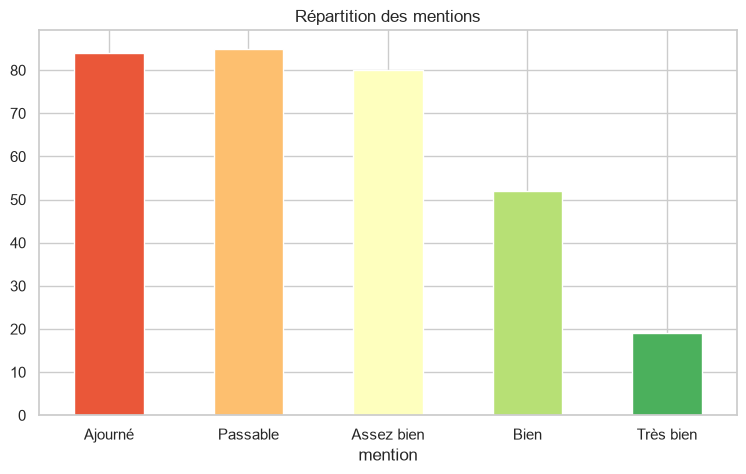

In [118]:
etu["mention"].value_counts().sort_index().plot.bar(rot=0, color=sns.color_palette("RdYlGn", 5), title="Répartition des mentions")
plt.show()

### Exercice 2.3 — Transformer

1. Créez `ecart_python_stats` = note de Python − note de Stats.
2. Créez `assidu` : `"oui"` si le taux de présence est ≥ 85 %, `"non"` sinon (`np.where`).
3. Créez `tranche_age` avec `pd.cut` : `19-21`, `22-25`, `26+`.

In [120]:
etu["ecart_python_stats"] = etu["note_python"] - etu["note_stats"]
etu["assidu"] = np.where(etu["taux_presence"] >= 85, "oui", "non")
etu["tranche_age"] = pd.cut(etu["age"], bins=[18, 21, 25, 40], labels=["19-21", "22-25", "26+"])
etu[["ecart_python_stats", "assidu", "tranche_age"]].head()

,ecart_python_stats,assidu,tranche_age
0,-3.00,non,22-25
1,2.80,non,26+
2,-0.40,non,26+
3,1.20,non,22-25
4,-0.90,non,22-25


### Regrouper et agréger : groupby

In [121]:
print(etu.groupby("filiere")["moyenne"].mean().sort_values(ascending=False).round(2), "\n")

synthese = (etu.groupby("filiere")
               .agg(effectif=("id_etudiant", "count"),
                    moyenne=("moyenne", "mean"),
                    taux_admis=("admis", "mean"))          # moyenne d'un booléen = proportion de True
               .sort_values("moyenne", ascending=False))
synthese

filiere
Maths          12.40
Physique       12.08
Informatique   11.78
Économie       11.27
Name: moyenne, dtype: float64 



,effectif,moyenne,taux_admis
filiere,,,
Maths,88,12.40,0.83
Physique,41,12.08,0.73
Informatique,112,11.78,0.71
Économie,79,11.27,0.67


filiere,Informatique,Maths,Physique,Économie
ville,,,,
Abomey-Calavi,29,22,12,22
Bohicon,18,5,8,4
Cotonou,35,27,11,31
Parakou,16,19,6,12
Porto-Novo,14,15,4,10


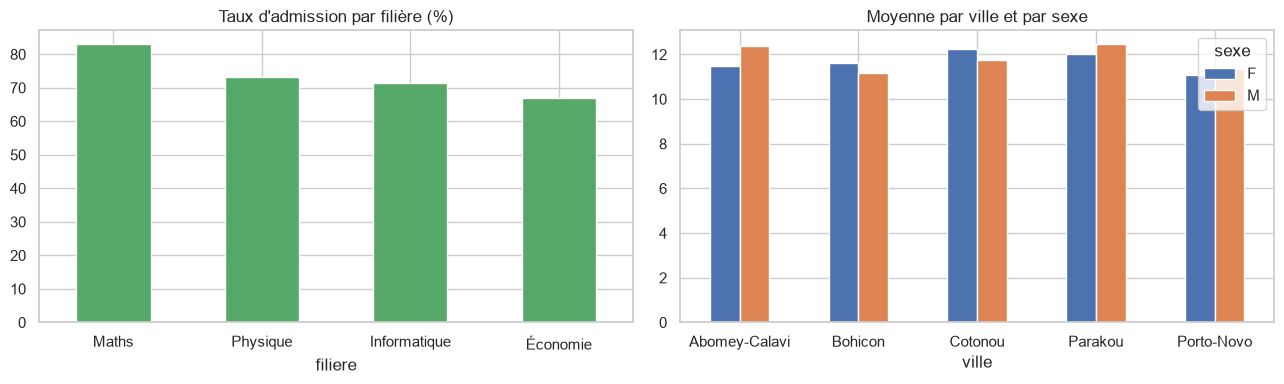

In [122]:
display(pd.crosstab(etu["ville"], etu["filiere"]))                              # effectifs croisés
par_ville_sexe = etu.groupby(["ville", "sexe"])["moyenne"].mean().unstack()     # unstack : sexe → colonnes

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
synthese["taux_admis"].mul(100).plot.bar(ax=axes[0], rot=0, color="#55a868",
                                         title="Taux d'admission par filière (%)")
par_ville_sexe.plot.bar(ax=axes[1], rot=0, title="Moyenne par ville et par sexe")
plt.tight_layout(); plt.show()

### Exercice 2.4 — Regrouper

1. Pour chaque **ville** : effectif, âge moyen et taux d'admission.
2. Quelle ville a le **meilleur taux d'admission** ? *(indice : `idxmax`)*
3. Avec `pd.crosstab(..., normalize="index")`, calculez le **pourcentage** de chaque mention (colonnes) dans chaque filière (lignes).

In [123]:
display(etu.groupby("ville").agg(effectif=("id_etudiant", "count"), age_moyen=("age", "mean"),
                                 taux_admis=("admis", "mean")).round(2))
taux = etu.groupby("ville")["admis"].mean()
print("Meilleure ville :", taux.idxmax(), f"({taux.max():.0%})")
pd.crosstab(etu["filiere"], etu["mention"], normalize="index").mul(100).round(1)

,effectif,age_moyen,taux_admis
ville,,,
Abomey-Calavi,85,25.58,0.74
Bohicon,35,24.89,0.66
Cotonou,104,26.36,0.75
Parakou,53,25.58,0.81
Porto-Novo,43,25.72,0.67


Meilleure ville : Parakou (81%)


mention,Ajourné,Passable,Assez bien,Bien,Très bien
filiere,,,,,
Informatique,28.60,26.80,20.50,17.90,6.20
Maths,17.00,28.40,29.50,18.20,6.80
Physique,26.80,22.00,24.40,19.50,7.30
Économie,32.90,26.60,26.60,10.10,3.80


### Combiner deux tables : merge

`gauche.merge(droite, on="cle", how=...)` rapproche deux tables grâce à une **clé commune** (l'équivalent du `JOIN` SQL) :
- `how="inner"` (défaut) : seulement les clés présentes **des deux côtés** ;
- `how="left"` : toutes les lignes de gauche (`NaN` si pas de correspondance à droite).


In [124]:
filieres = pd.read_csv(DATA / "filieres.csv")
display(filieres)

etu_f = etu.merge(filieres, on="filiere", how="left")
etu_f[["id_etudiant", "filiere", "departement", "frais_annuels_fcfa"]].head()

,filiere,departement,frais_annuels_fcfa,duree_ans
0,Maths,Sciences,250000,3
1,Informatique,Sciences & Tech.,350000,3
2,Économie,Sciences Sociales,225000,3
3,Physique,Sciences,250000,3
4,Biologie,Sciences de la Vie,275000,3


,id_etudiant,filiere,departement,frais_annuels_fcfa
0,E001,Économie,Sciences Sociales,225000
1,E002,Informatique,Sciences & Tech.,350000
2,E003,Physique,Sciences,250000
3,E004,Économie,Sciences Sociales,225000
4,E005,Maths,Sciences,250000


## Matplotlib 

In [125]:
## Anatomie d'une figure ...

# Figure : la « feuille » entière
# Axes : un graphique (zone de tracé, axes, titre, légende).
# On utilise l'interface orientée objet : fig, ax = plt.subplots(), puis ax.plot(...), ax.set_title(...), ax.set_xlabel(...), ax.legend()…

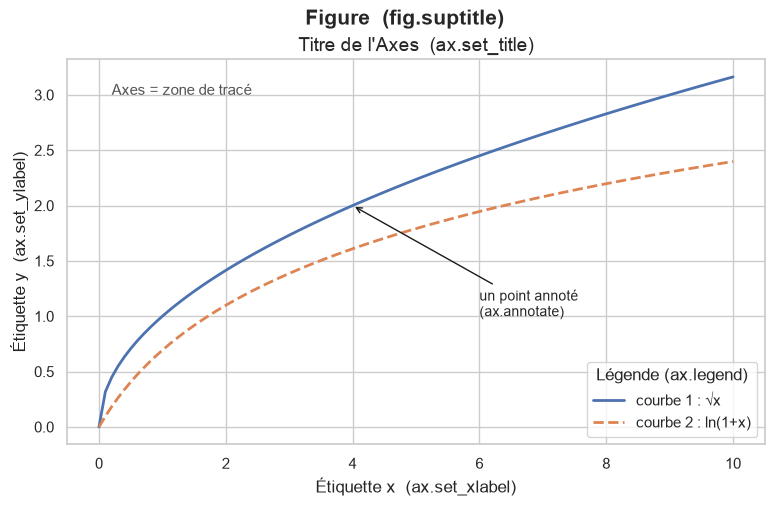

In [126]:
x = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, np.sqrt(x), lw=2, label="courbe 1 : √x")
ax.plot(x, np.log1p(x), lw=2, ls="--", label="courbe 2 : ln(1+x)")
ax.set_title("Titre de l'Axes  (ax.set_title)", fontsize=14)
ax.set_xlabel("Étiquette x  (ax.set_xlabel)"); ax.set_ylabel("Étiquette y  (ax.set_ylabel)")
ax.legend(title="Légende (ax.legend)")
ax.annotate("un point annoté\n(ax.annotate)", xy=(4, 2), xytext=(6, 1.0),
            arrowprops=dict(arrowstyle="->", color="k"), fontsize=10)
ax.text(0.2, 3.0, "Axes = zone de tracé", fontsize=11, color="#555")
fig.suptitle("Figure  (fig.suptitle)", fontsize=15, fontweight="bold")
plt.show()

### Un graphique  = une question 

In [127]:
# La courbe = comment ça évolue ? --> ax.plot
# Le nuage de points = Ces deux variables vont-elles ensemble ?  --> ax.scatter 
# Barres = Qui est devant ?  --> ax.bar / ax.barh
# Histogramme = Comment comparer des distributions ? boîte à moustaches --> ax.boxplot
# Camembert / Anneau = Quelle part du total ? --> ax.pie

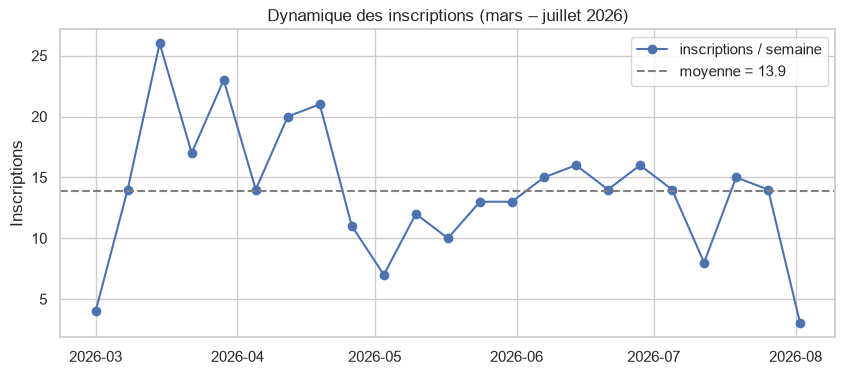

In [128]:
# courbe 

hebdo = etu.set_index("date_inscription").resample("W").size()     # nombre d'inscriptions par semaine

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hebdo.index, hebdo.values, marker="o", color="#4c72b0", label="inscriptions / semaine")
ax.axhline(hebdo.mean(), ls="--", color="gray", label=f"moyenne = {hebdo.mean():.1f}")
ax.set_title("Dynamique des inscriptions (mars – juillet 2026)")
ax.set_ylabel("Inscriptions"); ax.legend()
plt.show()

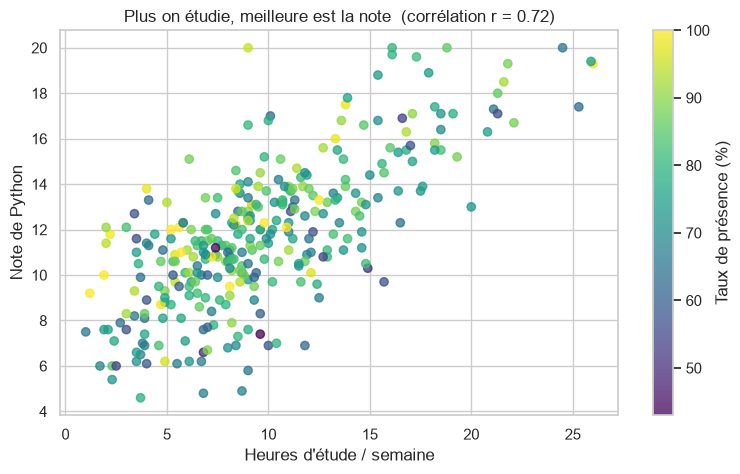

In [129]:
# nuage de points 
r = etu["heures_etude"].corr(etu["note_python"])

fig, ax = plt.subplots(figsize=(9, 5))
nuage = ax.scatter(etu["heures_etude"], etu["note_python"], c=etu["taux_presence"], cmap="viridis", alpha=0.75)
fig.colorbar(nuage, ax=ax, label="Taux de présence (%)")
ax.set_xlabel("Heures d'étude / semaine"); ax.set_ylabel("Note de Python")
ax.set_title(f"Plus on étudie, meilleure est la note  (corrélation r = {r:.2f})")
plt.show()


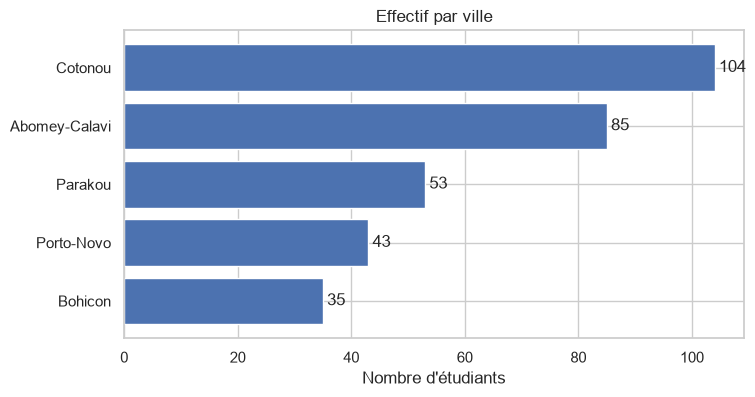

In [130]:
# barres

effectifs = etu["ville"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
barres = ax.barh(effectifs.index, effectifs.values, color="#4c72b0")
ax.bar_label(barres, padding=3)
ax.set_title("Effectif par ville"); ax.set_xlabel("Nombre d'étudiants")
plt.show()

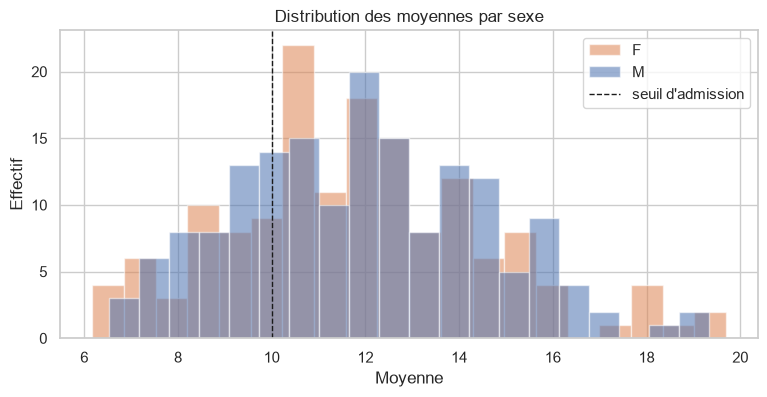

In [131]:
# histogramme 

fig, ax = plt.subplots(figsize=(9, 4))
for sexe, couleur in [("F", "#dd8452"), ("M", "#4c72b0")]:
    ax.hist(etu.loc[etu["sexe"] == sexe, "moyenne"], bins=20, alpha=0.55, color=couleur,
            label=sexe, edgecolor="white")
ax.axvline(10, color="k", ls="--", lw=1, label="seuil d'admission")
ax.set_xlabel("Moyenne"); ax.set_ylabel("Effectif"); ax.set_title("Distribution des moyennes par sexe")
ax.legend(); plt.show()

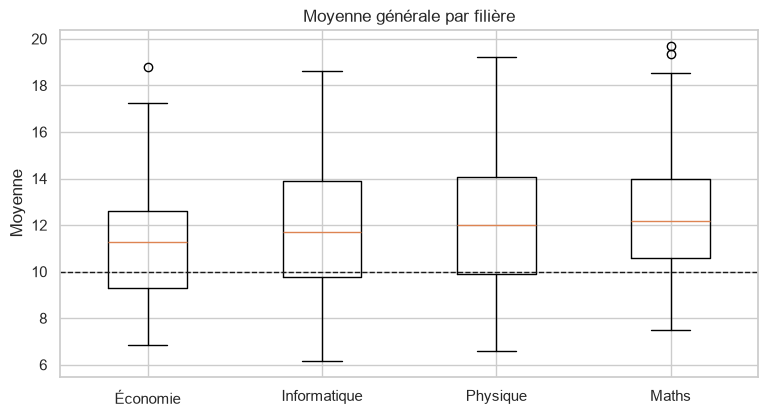

In [132]:
# boîte à moustaches 
ordre = etu.groupby("filiere")["moyenne"].median().sort_values().index
donnees = [etu.loc[etu["filiere"] == f, "moyenne"] for f in ordre]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot(donnees)
ax.set_xticks(range(1, len(ordre) + 1), ordre)
ax.axhline(10, color="k", ls="--", lw=1)
ax.set_ylabel("Moyenne"); ax.set_title("Moyenne générale par filière")
plt.show()


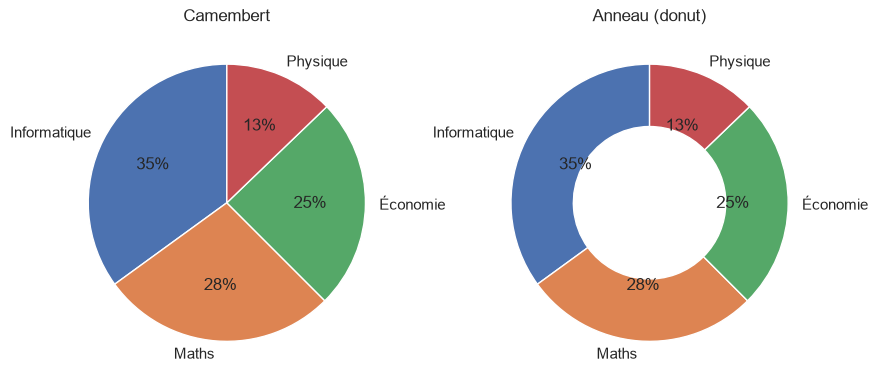

In [133]:
# camembert
# ici petit disclaimer ... à utiliser avec modération pour des soucis de lisibilité. au dela de 4-5 parts, préférez les barres ...

cnt = etu["filiere"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].pie(cnt, labels=cnt.index, autopct="%1.0f%%", startangle=90)
axes[0].set_title("Camembert")
axes[1].pie(cnt, labels=cnt.index, autopct="%1.0f%%", startangle=90,
            wedgeprops=dict(width=0.45, edgecolor="white"))            # anneau = camembert évidé
axes[1].set_title("Anneau (donut)")
plt.show()


### Exercice 3.1 — Le bon graphique pour la bonne question

Pour chaque question, **choisissez le type de graphique** adapté, puis tracez-le (titre et axes étiquetés) :
1. Comment la **moyenne générale évolue-t-elle avec l'âge** ? *(indice : `etu.groupby("age")["moyenne"].mean()`)*
2. Quelle filière a le **meilleur taux d'admission** ? Affichez les valeurs sur les barres et une ligne au niveau du taux global.
3. À quoi ressemble la **distribution des heures d'étude** ? Ajoutez la moyenne (rouge) et la médiane (vert) : la distribution est-elle symétrique ?

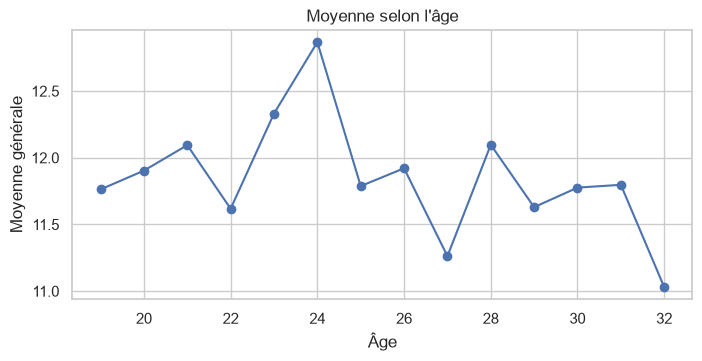

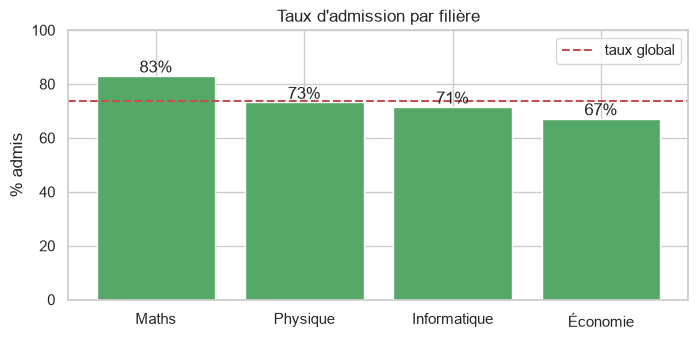

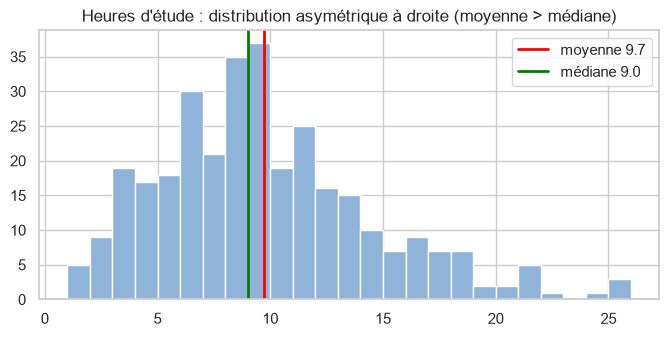

In [134]:

par_age = etu.groupby("age")["moyenne"].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(par_age.index, par_age.values, marker="o")
ax.set_xlabel("Âge"); ax.set_ylabel("Moyenne générale"); ax.set_title("Moyenne selon l'âge"); plt.show()

taux = etu.groupby("filiere")["admis"].mean().mul(100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.5))
b = ax.bar(taux.index, taux.values, color="#55a868")
ax.bar_label(b, fmt="%.0f%%")
ax.axhline(etu["admis"].mean() * 100, color="#c44e52", ls="--", label="taux global")
ax.set_ylim(0, 100); ax.set_ylabel("% admis"); ax.set_title("Taux d'admission par filière"); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(etu["heures_etude"], bins=25, color="#8fb3d9", edgecolor="white")
ax.axvline(etu["heures_etude"].mean(), color="red", lw=2, label=f"moyenne {etu['heures_etude'].mean():.1f}")
ax.axvline(etu["heures_etude"].median(), color="green", lw=2, label=f"médiane {etu['heures_etude'].median():.1f}")
ax.set_title("Heures d'étude : distribution asymétrique à droite (moyenne > médiane)"); ax.legend(); plt.show()

### Plusieurs graphiques et export 

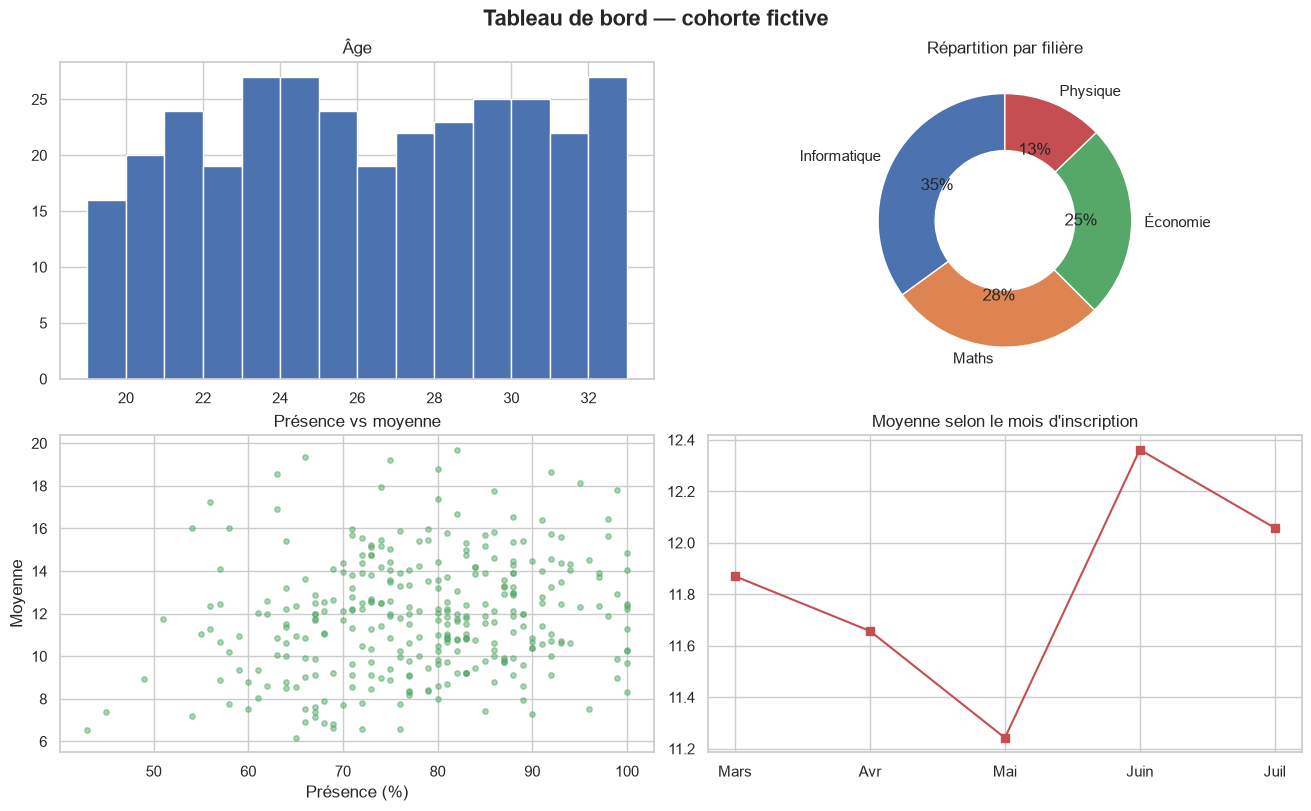

In [135]:
# Tableau de bord 2 × 2… puis export
fig, axes = plt.subplots(2, 2, figsize=(13, 8), layout="constrained")

axes[0, 0].hist(etu["age"], bins=range(19, 34), color="#4c72b0", edgecolor="white")
axes[0, 0].set_title("Âge")

cnt = etu["filiere"].value_counts()
axes[0, 1].pie(cnt, labels=cnt.index, autopct="%1.0f%%", startangle=90,
               wedgeprops=dict(width=0.45, edgecolor="white"))
axes[0, 1].set_title("Répartition par filière")

axes[1, 0].scatter(etu["taux_presence"], etu["moyenne"], alpha=0.5, s=15, color="#55a868")
axes[1, 0].set_xlabel("Présence (%)"); axes[1, 0].set_ylabel("Moyenne"); axes[1, 0].set_title("Présence vs moyenne")

par_mois = etu.groupby("mois_inscription")["moyenne"].mean()
axes[1, 1].plot(par_mois.index, par_mois.values, marker="s", color="#c44e52")
axes[1, 1].set_xticks(par_mois.index, ["Mars", "Avr", "Mai", "Juin", "Juil"])
axes[1, 1].set_title("Moyenne selon le mois d'inscription")

fig.suptitle("Tableau de bord — cohorte fictive", fontsize=16, fontweight="bold")
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/tableau_de_bord_etudiants.png", dpi=200, bbox_inches="tight")
plt.show()

### Exercice 3.2 — Sous-graphiques

Construisez une figure **1 ligne × 3 colonnes** avec `sharey=True` : pour chaque matière (Python, Stats, Algèbre),
l'histogramme des notes (20 intervalles) avec en titre la matière et la moyenne. Ajoutez un titre général.
*Astuce : `for ax, col in zip(axes, colonnes):` — et attention aux `NaN` de la note de Stats (`.dropna()`).*

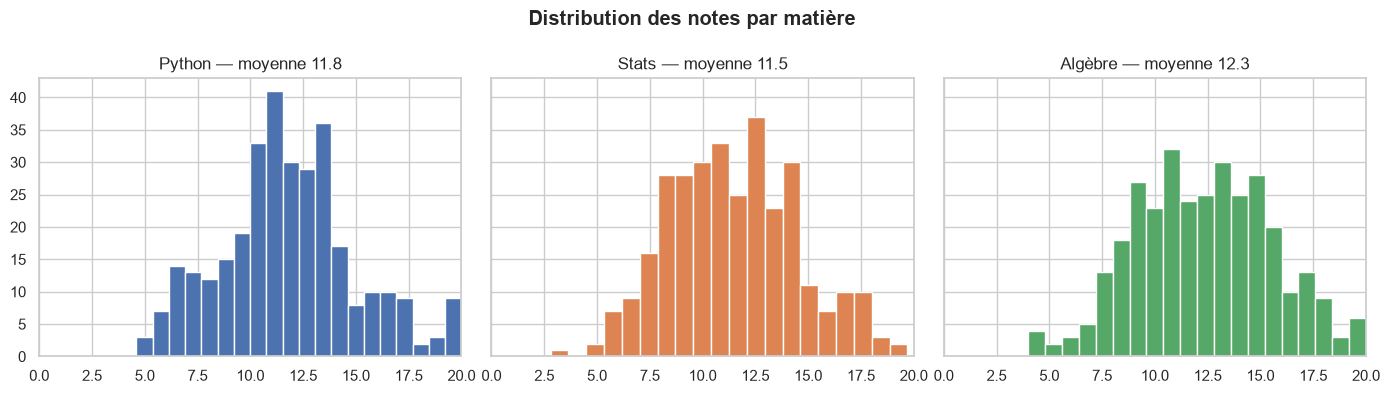

In [136]:
colonnes = {"note_python": "Python", "note_stats": "Stats", "note_algebre": "Algèbre"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (col, nom), couleur in zip(axes, colonnes.items(), sns.color_palette("deep")):
    ax.hist(etu[col].dropna(), bins=20, color=couleur, edgecolor="white")
    ax.set_title(f"{nom} — moyenne {etu[col].mean():.1f}")
    ax.set_xlim(0, 20)
fig.suptitle("Distribution des notes par matière", fontweight="bold"); plt.tight_layout(); plt.show()

## Seaborn 

In [137]:
## Construit sur Matplotlin et pensé pour les DataFrames, on passe data=df et des noms de colonnes x, y, hue, ...
# Il calcule lui même les statistiques (densités, moyennes, intervalles de confiance, régressions)

# Distribution --> histplot, kdeplot
# Catégories --> boxplot, stripplot, violinplot, countplot, barplot
# Relations --> scatterplot, regplot
# Matrices --> heatmap
# Vues d'ensembles / facettes --> pairplot, jointplot, lmplot(col=...)

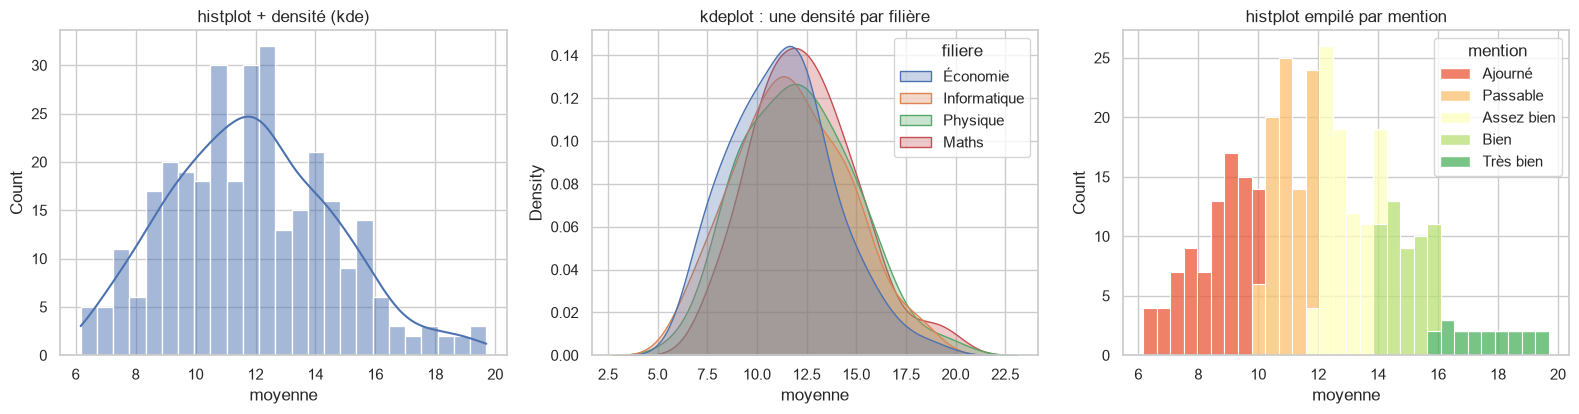

In [138]:
# Distribution

# Trois façons de regarder une distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))

sns.histplot(data=etu, x="moyenne", kde=True, bins=25, ax=axes[0])
axes[0].set_title("histplot + densité (kde)")

sns.kdeplot(data=etu, x="moyenne", hue="filiere", fill=True, common_norm=False, alpha=0.3, ax=axes[1])
axes[1].set_title("kdeplot : une densité par filière")

sns.histplot(data=etu, x="moyenne", hue="mention", multiple="stack", bins=30, palette="RdYlGn", ax=axes[2])
axes[2].set_title("histplot empilé par mention")
plt.tight_layout(); plt.show()


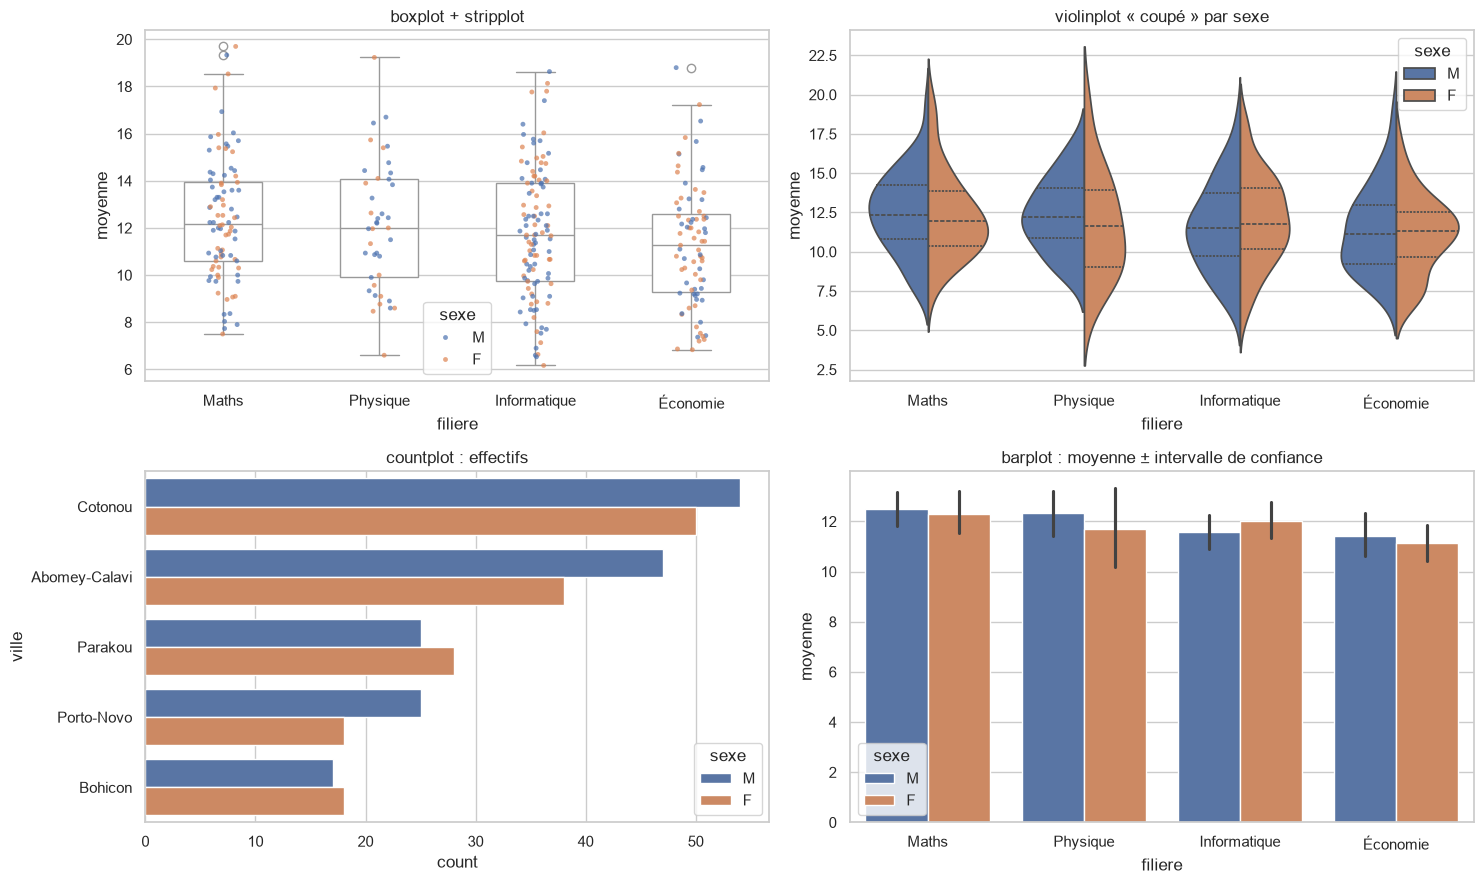

In [139]:
# variables catégorielles 

# Quatre graphiques catégoriels
ordre = etu.groupby("filiere")["moyenne"].median().sort_values(ascending=False).index
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

sns.boxplot(data=etu, x="filiere", y="moyenne", order=ordre, color="white", width=0.5, ax=axes[0, 0])
sns.stripplot(data=etu, x="filiere", y="moyenne", order=ordre, hue="sexe", size=3.5, alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title("boxplot + stripplot")

sns.violinplot(data=etu, x="filiere", y="moyenne", order=ordre, hue="sexe", split=True, inner="quart", ax=axes[0, 1])
axes[0, 1].set_title("violinplot « coupé » par sexe")

sns.countplot(data=etu, y="ville", order=etu["ville"].value_counts().index, hue="sexe", ax=axes[1, 0])
axes[1, 0].set_title("countplot : effectifs")

sns.barplot(data=etu, x="filiere", y="moyenne", order=ordre, hue="sexe", ax=axes[1, 1])
axes[1, 1].set_title("barplot : moyenne ± intervalle de confiance")
plt.tight_layout(); plt.show()

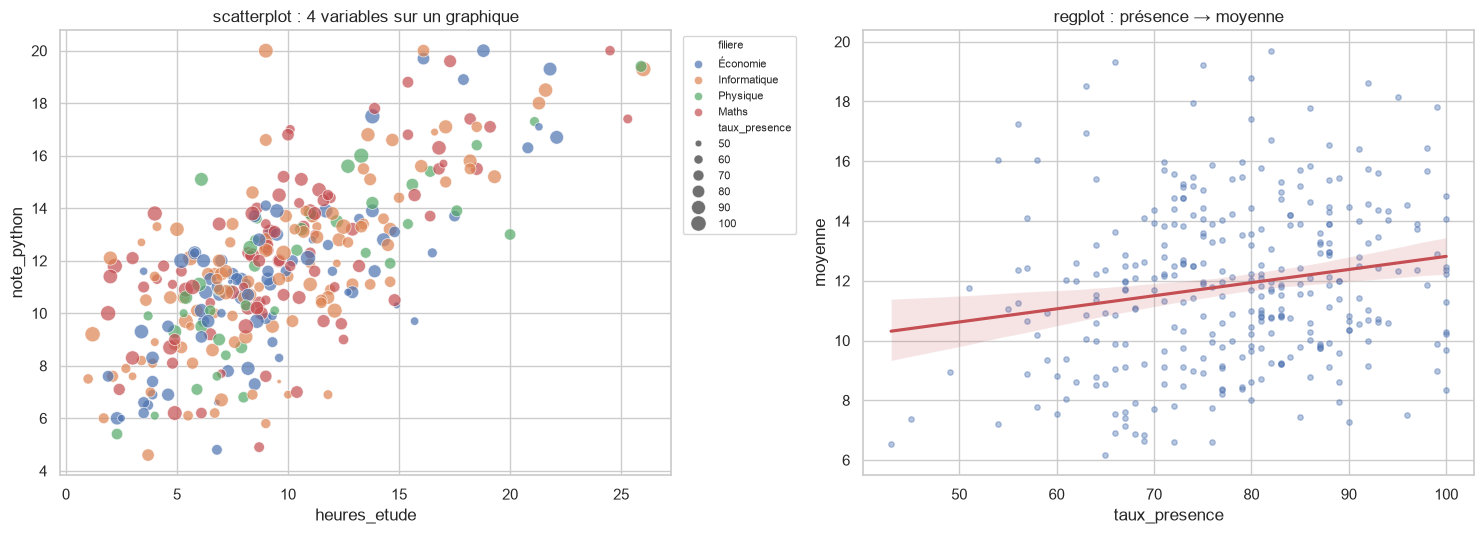

In [140]:
# relations entre variables numériques

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(data=etu, x="heures_etude", y="note_python", hue="filiere", size="taux_presence",
                sizes=(10, 120), alpha=0.7, ax=axes[0])
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].set_title("scatterplot : 4 variables sur un graphique")

sns.regplot(data=etu, x="taux_presence", y="moyenne", scatter_kws=dict(alpha=0.4, s=15),
            line_kws=dict(color="#c44e52"), ax=axes[1])
axes[1].set_title("regplot : présence → moyenne")
plt.tight_layout(); plt.show()

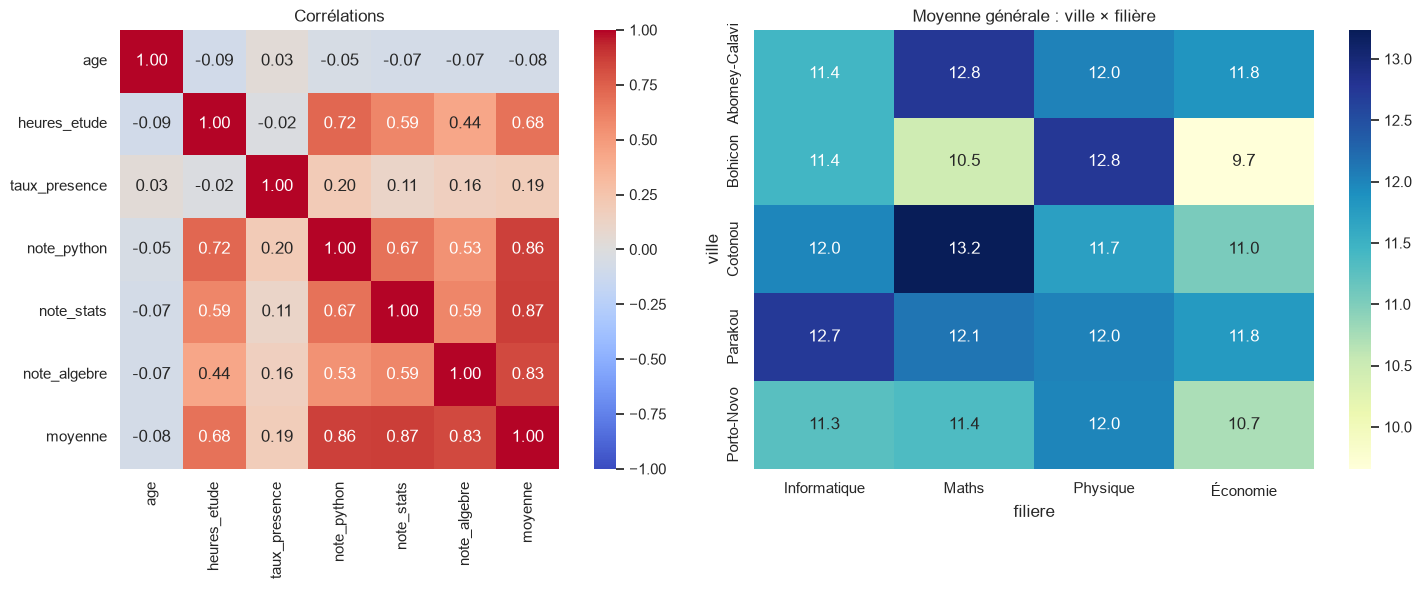

In [141]:
# matrices 

cols = ["age", "heures_etude", "taux_presence", "note_python", "note_stats", "note_algebre", "moyenne"]
corr = etu[cols].corr()
moy_ville_filiere = etu.groupby(["ville", "filiere"])["moyenne"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Corrélations")
sns.heatmap(moy_ville_filiere, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Moyenne générale : ville × filière")
plt.tight_layout(); plt.show()

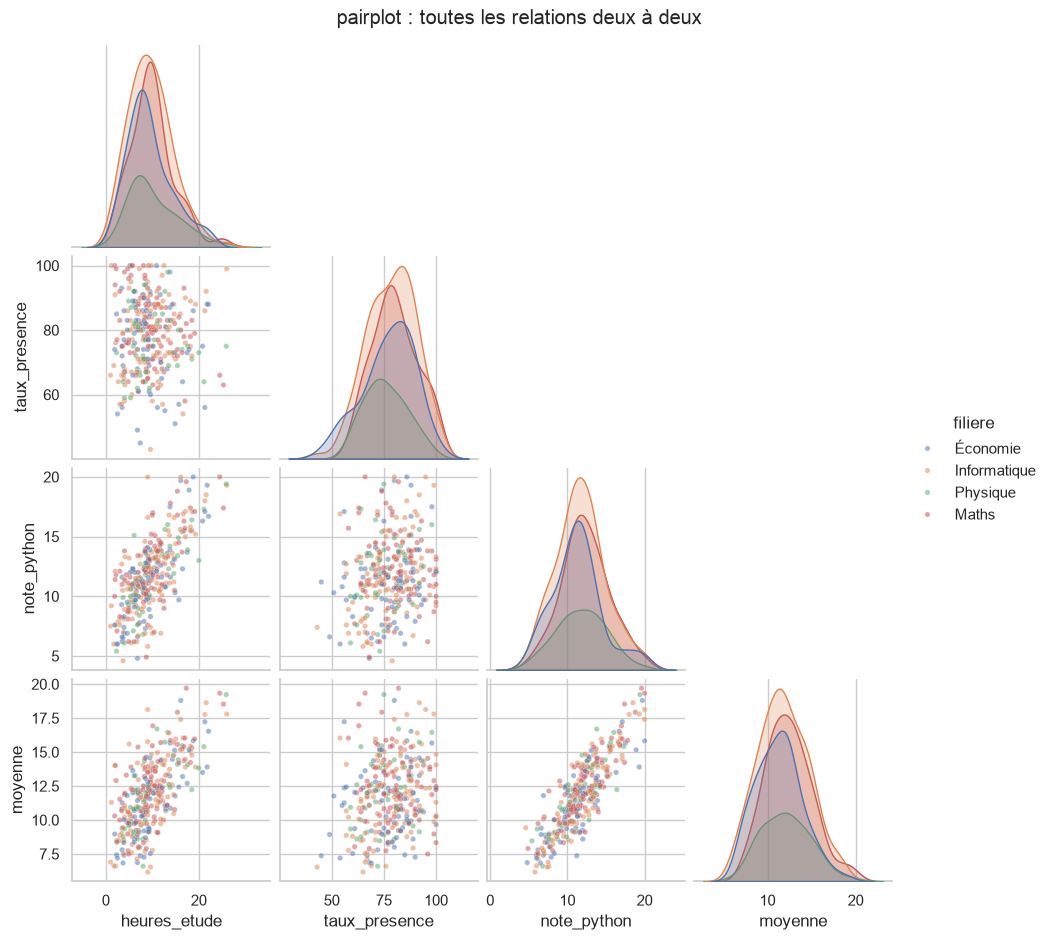

In [143]:
# vue d'ensemble & facettes 
# pairplot
g = sns.pairplot(etu, vars=["heures_etude", "taux_presence", "note_python", "moyenne"],
                 hue="filiere", corner=True, plot_kws=dict(alpha=0.5, s=15), height=2.3)
g.figure.suptitle("pairplot : toutes les relations deux à deux", y=1.02); plt.show()

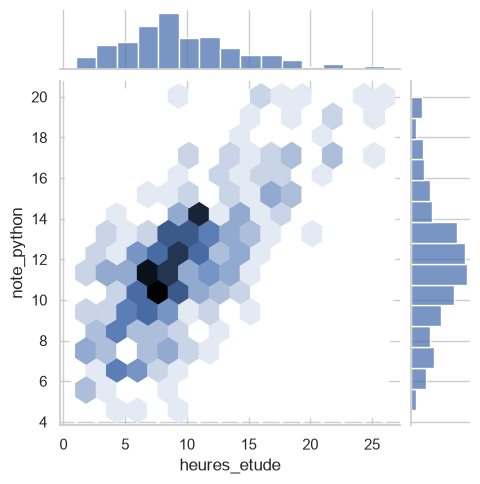

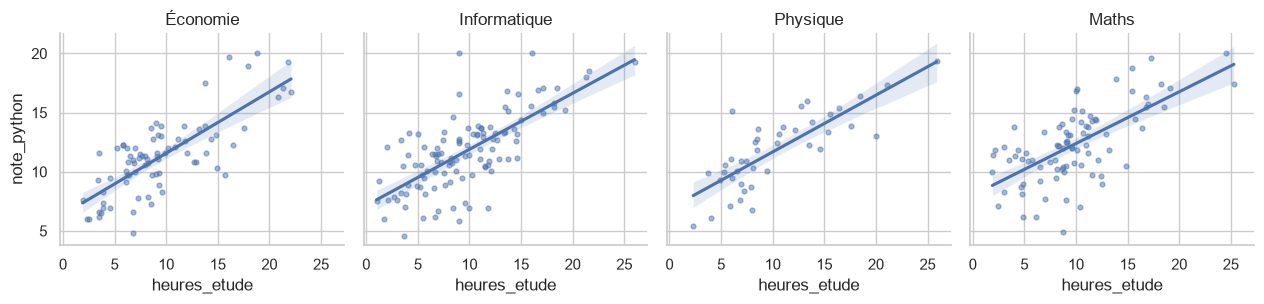

In [144]:
# jointplot (densité hexagonale)
sns.jointplot(data=etu, x="heures_etude", y="note_python", kind="hex", height=5, color="#4c72b0")
plt.show()

# Facettes : une régression par filière
g = sns.lmplot(data=etu, x="heures_etude", y="note_python", col="filiere", col_wrap=4, height=3.2,
               scatter_kws=dict(alpha=0.5, s=12))
g.set_titles("{col_name}"); plt.show()

### Exercice 4.1 — À vous de choisir

1. Avec `countplot`, affichez le nombre d'étudiants par **mention**, coloré par filière.
2. Avec `boxplot`, comparez le **taux de présence** selon la mention. Que remarquez-vous ?
3. Affichez en heatmap annotée le **% de chaque mention par filière** (le `crosstab` de l'exercice 2.4).

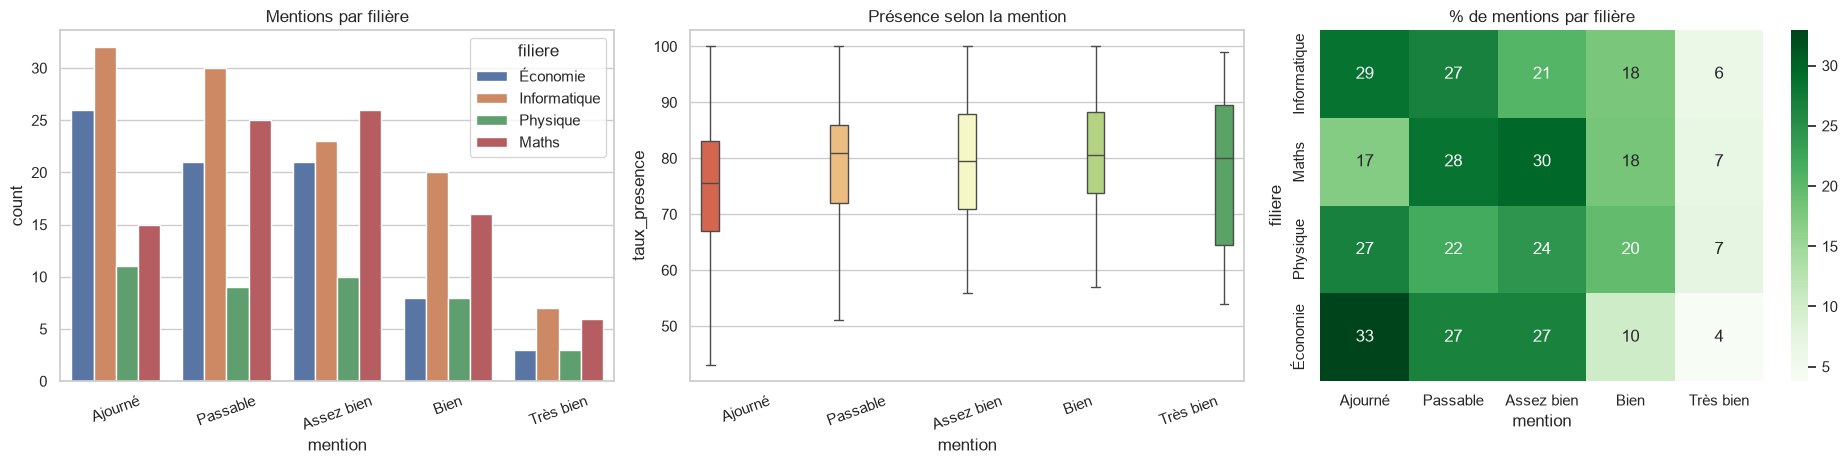

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

sns.countplot(data=etu, x="mention", hue="filiere", ax=axes[0])
axes[0].tick_params(axis="x", rotation=20); axes[0].set_title("Mentions par filière")

sns.boxplot(data=etu, x="mention", y="taux_presence", hue="mention", palette="RdYlGn", legend=False, ax=axes[1])
axes[1].tick_params(axis="x", rotation=20); axes[1].set_title("Présence selon la mention")

ct = pd.crosstab(etu["filiere"], etu["mention"], normalize="index") * 100
sns.heatmap(ct, annot=True, fmt=".0f", cmap="Greens", ax=axes[2]); axes[2].set_title("% de mentions par filière")
plt.tight_layout(); plt.show()

# Mini Projet :)

---
## Les ventes 2025 de *MarchéPlus*


### Contexte

*MarchéPlus* est une chaîne **fictive** de 6 supermarchés (Cotonou, Abomey-Calavi, Porto-Novo, Parakou, Bohicon).
La direction nous confie l'historique des ventes 2025 et nous pose six questions. Chacune appelle des graphiques différents :

| # | Question métier | Graphiques |
|---|---|---|
| **Q1** | Quels magasins performent le mieux ? | barres horizontales |
| **Q2** | Quelles catégories génèrent le chiffre d'affaires ? | barres groupées, nuage « à bulles » |
| **Q3** | Y a-t-il une saisonnalité ? | courbe, heatmap |
| **Q4** | Le **Mobile Money** progresse-t-il ? | aires empilées, barres empilées à 100 % |
| **Q5** | Un magasin pose-t-il un problème de **satisfaction** ? | barres, courbe |
| **Q6** | Les **remises** font-elles vraiment acheter plus ? | points, barres |

### Les données

- `ventes` : une ligne = un article passé en caisse — `date_heure`, `id_magasin`, `id_produit`, `quantite`,
  `remise_pct` (0, 5, 10 ou 15 %), `mode_paiement`, `age_client`, `sexe_client`, `satisfaction` (1 à 5) ;
- `produits` : `nom_produit`, `categorie`, `prix_unitaire` (FCFA) ;
- `magasins` : `ville`, `quartier`, `surface_m2`, `date_ouverture`.


In [147]:
# Charger les données et repérer les défauts 

ventes = pd.read_csv(DATA / "ventes.csv")
produits = pd.read_csv(DATA / "produits.csv")
magasins = pd.read_csv(DATA / "magasins.csv")

for nom, table in [("ventes", ventes), ("produits", produits), ("magasins", magasins)]:
    print(f"{nom:<9} : {table.shape[0]:>6} lignes × {table.shape[1]} colonnes")
display(ventes.head())

ventes    :  12040 lignes × 10 colonnes
produits  :     27 lignes × 4 colonnes
magasins  :      6 lignes × 5 colonnes


,id_transaction,date_heure,id_magasin,id_produit,quantite,remise_pct,mode_paiement,age_client,sexe_client,satisfaction
0,T00001,2025-01-01 10:37,M03,P024,1,0,Espèces,18.00,F,3.00
1,T00002,2025-01-01 10:49,M03,P015,1,0,Espèces,47.00,M,4.00
2,T00003,2025-01-01 10:50,M04,P024,1,0,Carte,18.00,F,1.00
3,T00004,2025-01-01 11:08,M04,P004,2,0,Mobile Money,19.00,F,2.00
4,T00005,2025-01-01 11:28,M02,P001,6,0,Mobile Money,35.00,F,4.00


Doublons : 40
age_client      250
satisfaction     10
dtype: int64


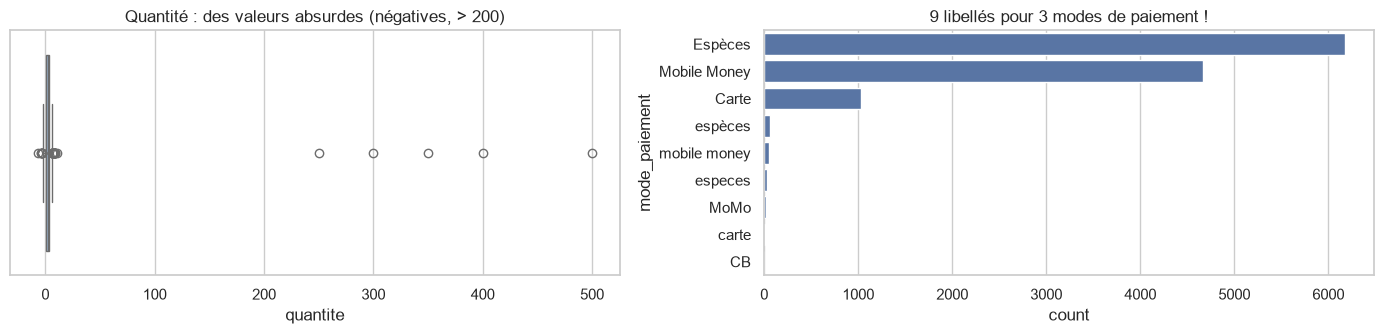

In [149]:

print("Doublons :", ventes.duplicated().sum())
manquants = ventes.isna().sum()
print(manquants[manquants > 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
sns.boxplot(x=ventes["quantite"], color="#8fb3d9", ax=axes[0])
axes[0].set_title("Quantité : des valeurs absurdes (négatives, > 200)")
sns.countplot(data=ventes, y="mode_paiement", order=ventes["mode_paiement"].value_counts().index, ax=axes[1])
axes[1].set_title(f"{ventes['mode_paiement'].nunique()} libellés pour 3 modes de paiement !")
plt.tight_layout(); plt.show()

In [151]:
# Préparation de données 

n0 = len(ventes)
v = ventes.drop_duplicates().copy()
v["date_heure"] = pd.to_datetime(v["date_heure"])

# exactement 3 modes de paiement
harmonisation = {"espèces": "Espèces", "especes": "Espèces", "mobile money": "Mobile Money",
                 "momo": "Mobile Money", "carte": "Carte", "cb": "Carte"}
v["mode_paiement"] = v["mode_paiement"].str.lower().map(harmonisation)

# quantités absurdes (retours, fautes de frappe) → écartées
v = v[(v["quantite"] > 0) & (v["quantite"] <= 50)]

# jointures : chaque vente reçoit les informations de son produit et de son magasin
df = (v.merge(produits, on="id_produit", how="left")
       .merge(magasins, on="id_magasin", how="left"))

# nouvelles variables
df["montant"] = df["quantite"] * df["prix_unitaire"] * (1 - df["remise_pct"] / 100)
df["mois"] = df["date_heure"].dt.month
df["heure"] = df["date_heure"].dt.hour
JOURS = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
df["jour"] = pd.Categorical(df["date_heure"].dt.dayofweek.map(dict(enumerate(JOURS))),
                            categories=JOURS, ordered=True)                 # ordre lundi → dimanche
df["magasin"] = df["id_magasin"] + " · " + df["ville"]
MOIS = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin", "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

print(f"{n0} lignes brutes → {len(df)} lignes propres ({n0 - len(df)} écartées)")
df[["date_heure", "magasin", "nom_produit", "categorie", "quantite", "remise_pct", "montant", "jour"]].head()


12040 lignes brutes → 11980 lignes propres (60 écartées)


,date_heure,magasin,nom_produit,categorie,quantite,remise_pct,montant,jour
0,2025-01-01 10:37:00,M03 · Abomey-Calavi,Seau 15 L,Maison,1,0,"2,000.00",Mercredi
1,2025-01-01 10:49:00,M03 · Abomey-Calavi,Dentifrice 100 ml,Hygiène,1,0,900.00,Mercredi
2,2025-01-01 10:50:00,M04 · Porto-Novo,Seau 15 L,Maison,1,0,"2,000.00",Mercredi
3,2025-01-01 11:08:00,M04 · Porto-Novo,Gari 1 kg,Alimentation,2,0,"1,200.00",Mercredi
4,2025-01-01 11:28:00,M02 · Cotonou,Riz parfumé 5 kg,Alimentation,6,0,"27,000.00",Mercredi


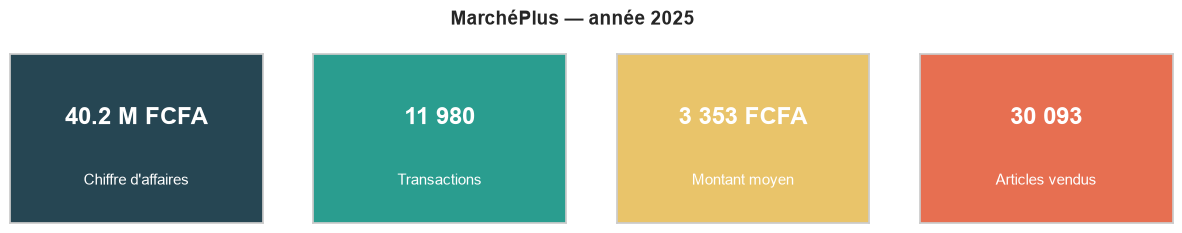

In [153]:
# Chiffres clés 

kpi = {
    "Chiffre d'affaires": f"{df['montant'].sum() / 1e6:,.1f} M FCFA",
    "Transactions": f"{len(df):,}".replace(",", " "),
    "Montant moyen": f"{df['montant'].mean():,.0f} FCFA".replace(",", " "),
    "Articles vendus": f"{df['quantite'].sum():,}".replace(",", " "),
}
fig, axes = plt.subplots(1, 4, figsize=(15, 2.2))
for ax, (titre, valeur), couleur in zip(axes, kpi.items(), ["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]):
    ax.set_facecolor(couleur); ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, valeur, ha="center", va="center", fontsize=17, fontweight="bold", color="white")
    ax.text(0.5, 0.25, titre, ha="center", va="center", fontsize=11, color="white")
fig.suptitle("MarchéPlus — année 2025", fontsize=14, fontweight="bold", y=1.08); plt.show()

## Q1 — Quels magasins performent le mieux ?

Hypothèse : « le plus grand magasin est le meilleur »… vraiment ? On compare le chiffre d'affaires (CA) brut
et le **CA par m²** (la rentabilité de la surface).

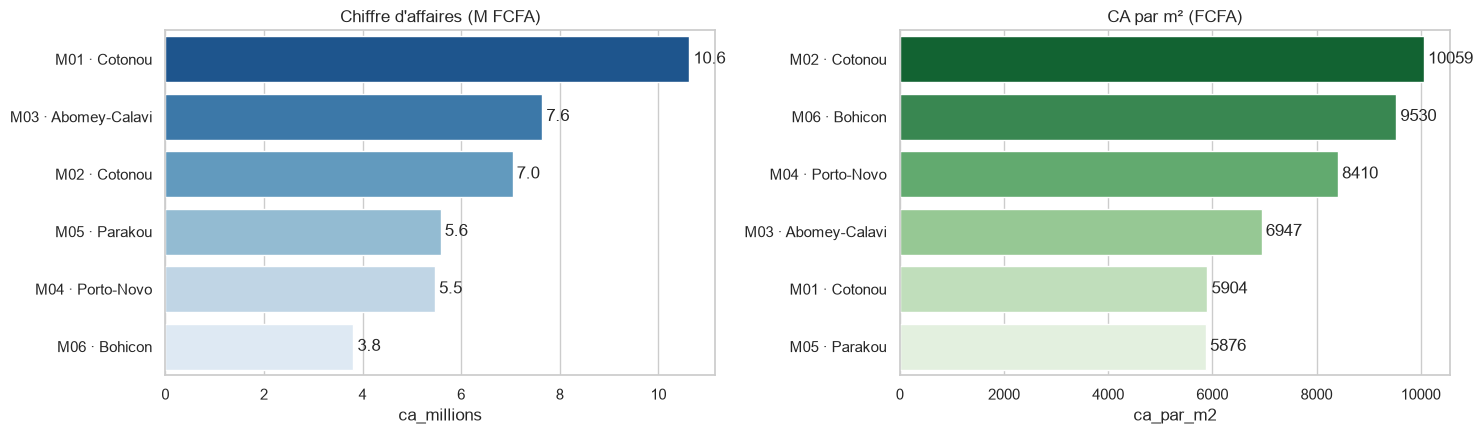

In [154]:
perf = (df.groupby(["magasin", "surface_m2"])
          .agg(ca=("montant", "sum"), transactions=("id_transaction", "count"))
          .reset_index())
perf["ca_millions"] = perf["ca"] / 1e6
perf["ca_par_m2"] = perf["ca"] / perf["surface_m2"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, col, titre, pal in [(axes[0], "ca_millions", "Chiffre d'affaires (M FCFA)", "Blues_r"),
                            (axes[1], "ca_par_m2", "CA par m² (FCFA)", "Greens_r")]:
    d = perf.sort_values(col, ascending=False)
    sns.barplot(data=d, y="magasin", x=col, hue="magasin", palette=pal, legend=False, ax=ax)
    for c in ax.containers:                                   # un conteneur de barres par magasin
        ax.bar_label(c, fmt="%.1f" if col == "ca_millions" else "%.0f", padding=3)
    ax.set_title(titre); ax.set_ylabel("")
plt.tight_layout(); plt.show()

> Ganhi (M01, Cotonou) fait de loin le plus gros chiffre d'affaires (≈ 10,6 M FCFA)… mais c'est, avec Parakou,
> le magasin qui rentabilise le **moins** sa surface (≈ 5 900 FCFA/m²). Les petits formats **Fidjrossè (M02)** et **Bohicon (M06)**
> dépassent 9 500 FCFA/m² → ne jamais juger un magasin sur le CA brut seul ; les petits formats sont une piste d'expansion.

## Q2 — Quelles catégories génèrent le chiffre d'affaires ?

1. Poids de chaque catégorie en **volume** (part des transactions) et en **valeur** (part du CA) : barres groupées.
2. La **carte des produits** : prix (échelle log) × unités vendues, taille de la bulle = CA.

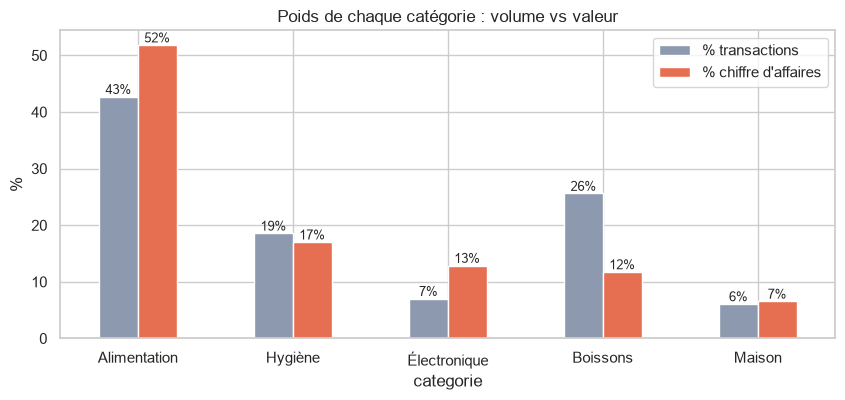

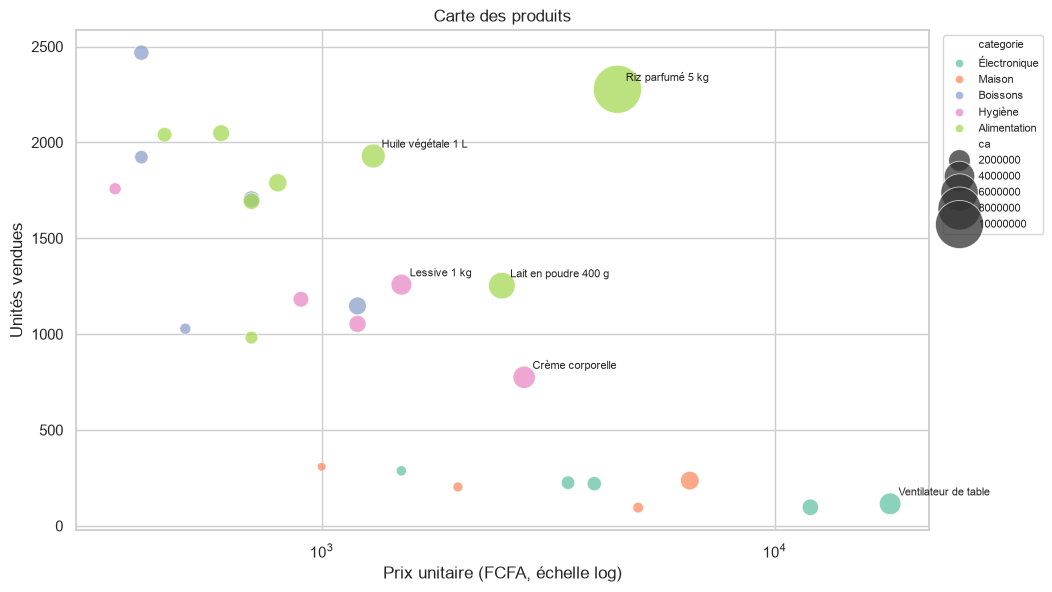

In [155]:
parts = pd.DataFrame({
    "% transactions": df["categorie"].value_counts(normalize=True) * 100,
    "% chiffre d'affaires": df.groupby("categorie")["montant"].sum() / df["montant"].sum() * 100,
}).sort_values("% chiffre d'affaires", ascending=False)
ax = parts.plot.bar(rot=0, figsize=(10, 4), color=["#8d99ae", "#e76f51"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", fontsize=9)
ax.set_title("Poids de chaque catégorie : volume vs valeur"); ax.set_ylabel("%"); plt.show()

carte = (df.groupby(["nom_produit", "categorie", "prix_unitaire"])
           .agg(quantite=("quantite", "sum"), ca=("montant", "sum")).reset_index())
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.scatterplot(data=carte, x="prix_unitaire", y="quantite", size="ca", sizes=(40, 1200),
                hue="categorie", palette="Set2", alpha=0.75, ax=ax)
for _, ligne in carte.nlargest(6, "ca").iterrows():                          # on nomme les 6 plus gros CA
    ax.annotate(ligne["nom_produit"], (ligne["prix_unitaire"], ligne["quantite"]), fontsize=8,
                xytext=(6, 6), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("Prix unitaire (FCFA, échelle log)"); ax.set_ylabel("Unités vendues")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8); ax.set_title("Carte des produits"); plt.show()

> l'alimentation domine en volume **et** en valeur (≈ 43 % des transactions, ≈ 52 % du CA ; le riz 5 kg est le premier produit).
> L'électronique ne représente que ≈ 7 % des transactions mais ≈ 13 % du CA : peu de ventes, mais à forte valeur unitaire.
> À l'inverse, les boissons pèsent lourd en volume (≈ 26 %) mais peu en valeur (≈ 12 %).

## Q3 — Y a-t-il une saisonnalité ?

À votre avis : quel est le meilleur mois ? le meilleur jour ? la meilleure heure ?
1. CA mensuel (courbe) ; 2. affluence **jour de la semaine × heure** (heatmap).

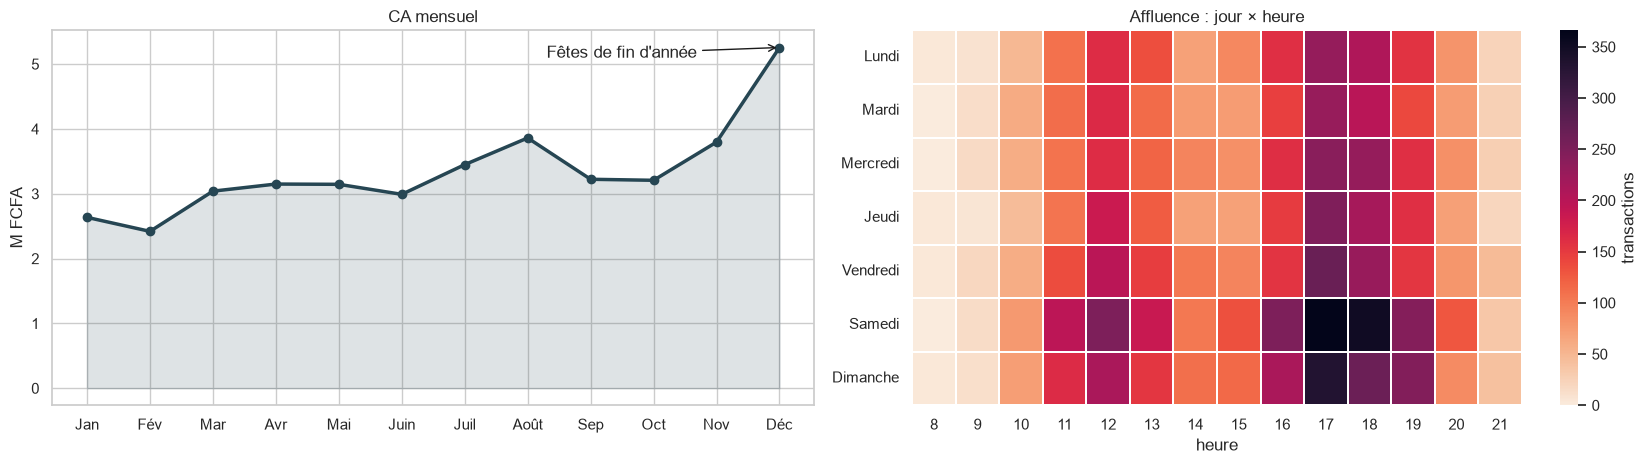

In [156]:
mensuel = df.groupby("mois")["montant"].sum() / 1e6
grille = pd.crosstab(df["jour"], df["heure"])                # nombre de transactions par case

fig, axes = plt.subplots(1, 2, figsize=(17, 4.8))
axes[0].plot(mensuel.index, mensuel.values, marker="o", lw=2.5, color="#264653")
axes[0].fill_between(mensuel.index, mensuel.values, alpha=0.15, color="#264653")   # aire sous la courbe
axes[0].annotate("Fêtes de fin d'année", xy=(12, mensuel[12]), xytext=(8.3, mensuel[12] * 0.97),
                 arrowprops=dict(arrowstyle="->", color="k"))
axes[0].set_xticks(range(1, 13), MOIS); axes[0].set_ylabel("M FCFA"); axes[0].set_title("CA mensuel")

sns.heatmap(grille, cmap="rocket_r", linewidths=0.3, cbar_kws=dict(label="transactions"), ax=axes[1])
axes[1].set_title("Affluence : jour × heure"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

> forte saisonnalité : **pic en décembre** (≈ +55 % par rapport à un mois moyen), creux en janvier-février.
> Le **samedi** est de loin le jour le plus fréquenté. Deux pics horaires : **midi** et surtout **17h-19h**
> → renforcer les caisses le samedi et en fin de journée.

## Q4 — Le Mobile Money progresse-t-il ?

1. Part mensuelle de chaque mode de paiement : **aires empilées** (`crosstab(normalize="index")` puis `.plot.area()`) ;
2. Répartition par ville : **barres empilées à 100 %**.

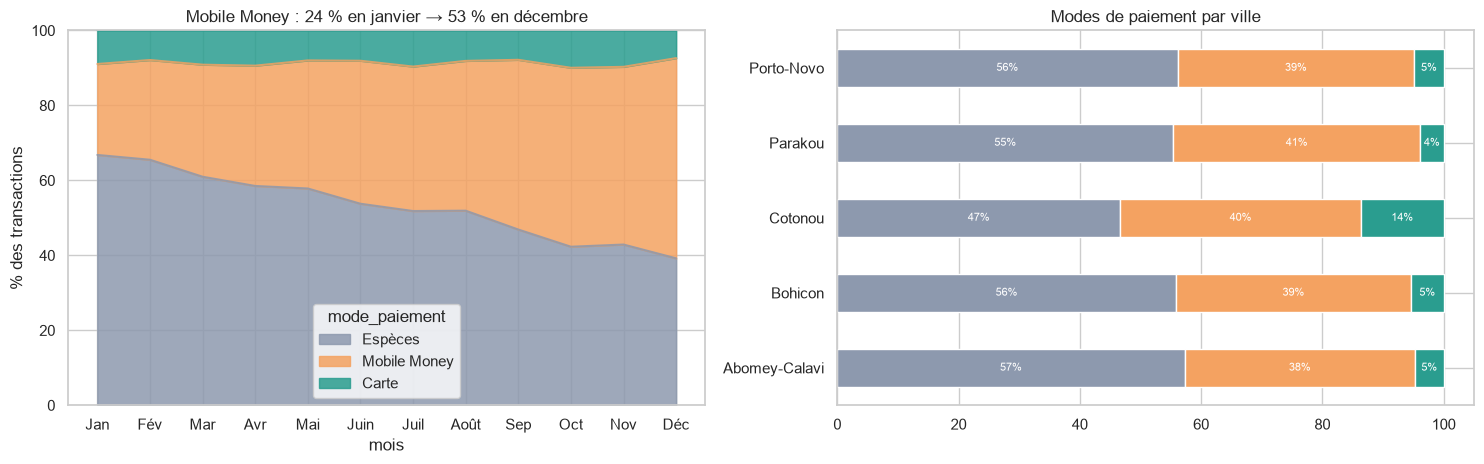

In [157]:
modes = ["Espèces", "Mobile Money", "Carte"]
couleurs = ["#8d99ae", "#f4a261", "#2a9d8f"]
parts_mois = pd.crosstab(df["mois"], df["mode_paiement"], normalize="index")[modes] * 100
par_ville = pd.crosstab(df["ville"], df["mode_paiement"], normalize="index")[modes] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
parts_mois.plot.area(ax=axes[0], color=couleurs, alpha=0.85)
axes[0].set_xticks(range(1, 13), MOIS); axes[0].set_ylim(0, 100); axes[0].set_ylabel("% des transactions")
axes[0].set_title(f"Mobile Money : {parts_mois.loc[1, 'Mobile Money']:.0f} % en janvier → "
                  f"{parts_mois.loc[12, 'Mobile Money']:.0f} % en décembre")

par_ville.plot.barh(stacked=True, ax=axes[1], color=couleurs, legend=False)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f%%", label_type="center", fontsize=8, color="white")
axes[1].set_title("Modes de paiement par ville"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

> la part du Mobile Money **progresse tout au long de l'année** (≈ 24 % des transactions en janvier → ≈ 53 % en décembre),
> au détriment des espèces. La carte bancaire reste marginale, sauf à Cotonou → priorité à la fluidité du paiement mobile
> plutôt qu'aux terminaux carte hors Cotonou.

## Q5 — Un magasin pose-t-il un problème de satisfaction ?

1. Satisfaction moyenne par magasin (barres triées + moyenne globale) ;
2. Satisfaction selon l'heure de passage (`lineplot` : moyenne par heure + bande de confiance).

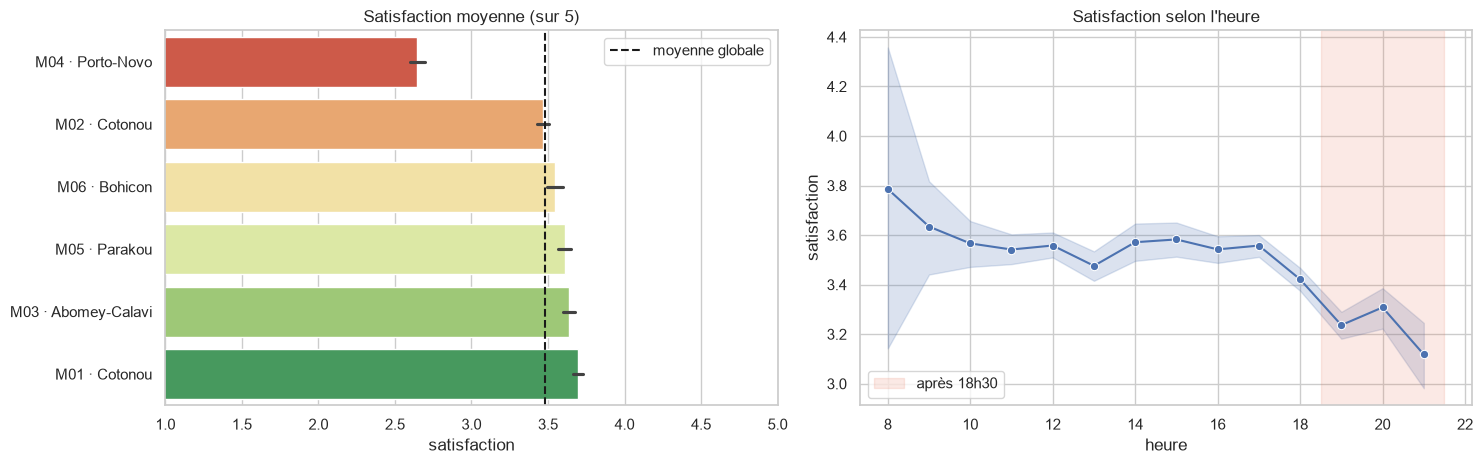

In [158]:
ordre_s = df.groupby("magasin")["satisfaction"].mean().sort_values().index
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

sns.barplot(data=df, y="magasin", x="satisfaction", order=ordre_s, hue="magasin", hue_order=ordre_s,
            palette="RdYlGn", legend=False, ax=axes[0])
axes[0].axvline(df["satisfaction"].mean(), color="k", ls="--", label="moyenne globale")
axes[0].set_xlim(1, 5); axes[0].legend(); axes[0].set_title("Satisfaction moyenne (sur 5)"); axes[0].set_ylabel("")

sns.lineplot(data=df, x="heure", y="satisfaction", marker="o", ax=axes[1])
axes[1].axvspan(18.5, 21.5, color="#e76f51", alpha=0.15, label="après 18h30")
axes[1].legend(); axes[1].set_title("Satisfaction selon l'heure")
plt.tight_layout(); plt.show()

> le magasin **M04 · Porto-Novo** décroche nettement (≈ 2,7/5 contre ≈ 3,6/5 ailleurs) → audit à prévoir.
> La satisfaction baisse aussi **en soirée**, au moment de la plus forte affluence : cohérent avec l'attente en caisse (Q3).

## Q6 — Les remises font-elles vraiment acheter plus ?

1. Quantité moyenne achetée selon le taux de remise (`pointplot`), pour les produits courants ;
2. Part des transactions remisées par mois.
3. Peut-on conclure à un **lien de causalité** ?

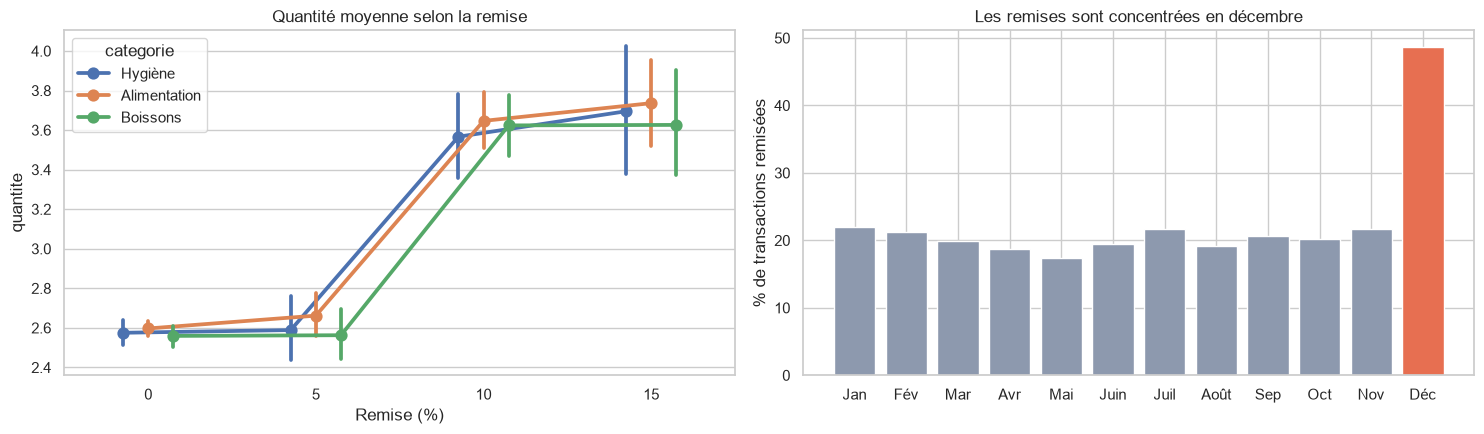

In [159]:
courant = df[df["categorie"].isin(["Alimentation", "Boissons", "Hygiène"])]
df["remisee"] = df["remise_pct"] > 0
part_rem = df.groupby("mois")["remisee"].mean() * 100           # moyenne d'un booléen = proportion

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.pointplot(data=courant, x="remise_pct", y="quantite", hue="categorie", dodge=0.3, ax=axes[0])
axes[0].set_xlabel("Remise (%)"); axes[0].set_title("Quantité moyenne selon la remise")

axes[1].bar(part_rem.index, part_rem.values, color=np.where(part_rem.index == 12, "#e76f51", "#8d99ae"))
axes[1].set_xticks(range(1, 13), MOIS); axes[1].set_ylabel("% de transactions remisées")
axes[1].set_title("Les remises sont concentrées en décembre")
plt.tight_layout(); plt.show()

> les quantités augmentent nettement à partir de 10 % de remise. **Mais** les remises sont surtout accordées en
> décembre, période où l'on achète de toute façon davantage : c'est une **variable de confusion**.

## Étape finale — Le tableau de bord de direction


/Users/ounzin/.pyenv/versions/orca/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/ounzin/.pyenv/versions/orca/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/ounzin/.pyenv/versions/orca/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/ounzin/.pyenv/versions/orca/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/ll/hh46rpg97xj70b3xkn0f2t3m0000gn/T/ipykernel_65864/961577653.py:33: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  fig.savefig("figures/tableau_de_bord_marcheplus.png", dpi=200, bbox_inches="tight")
/var/folders/ll/hh46rpg97xj70

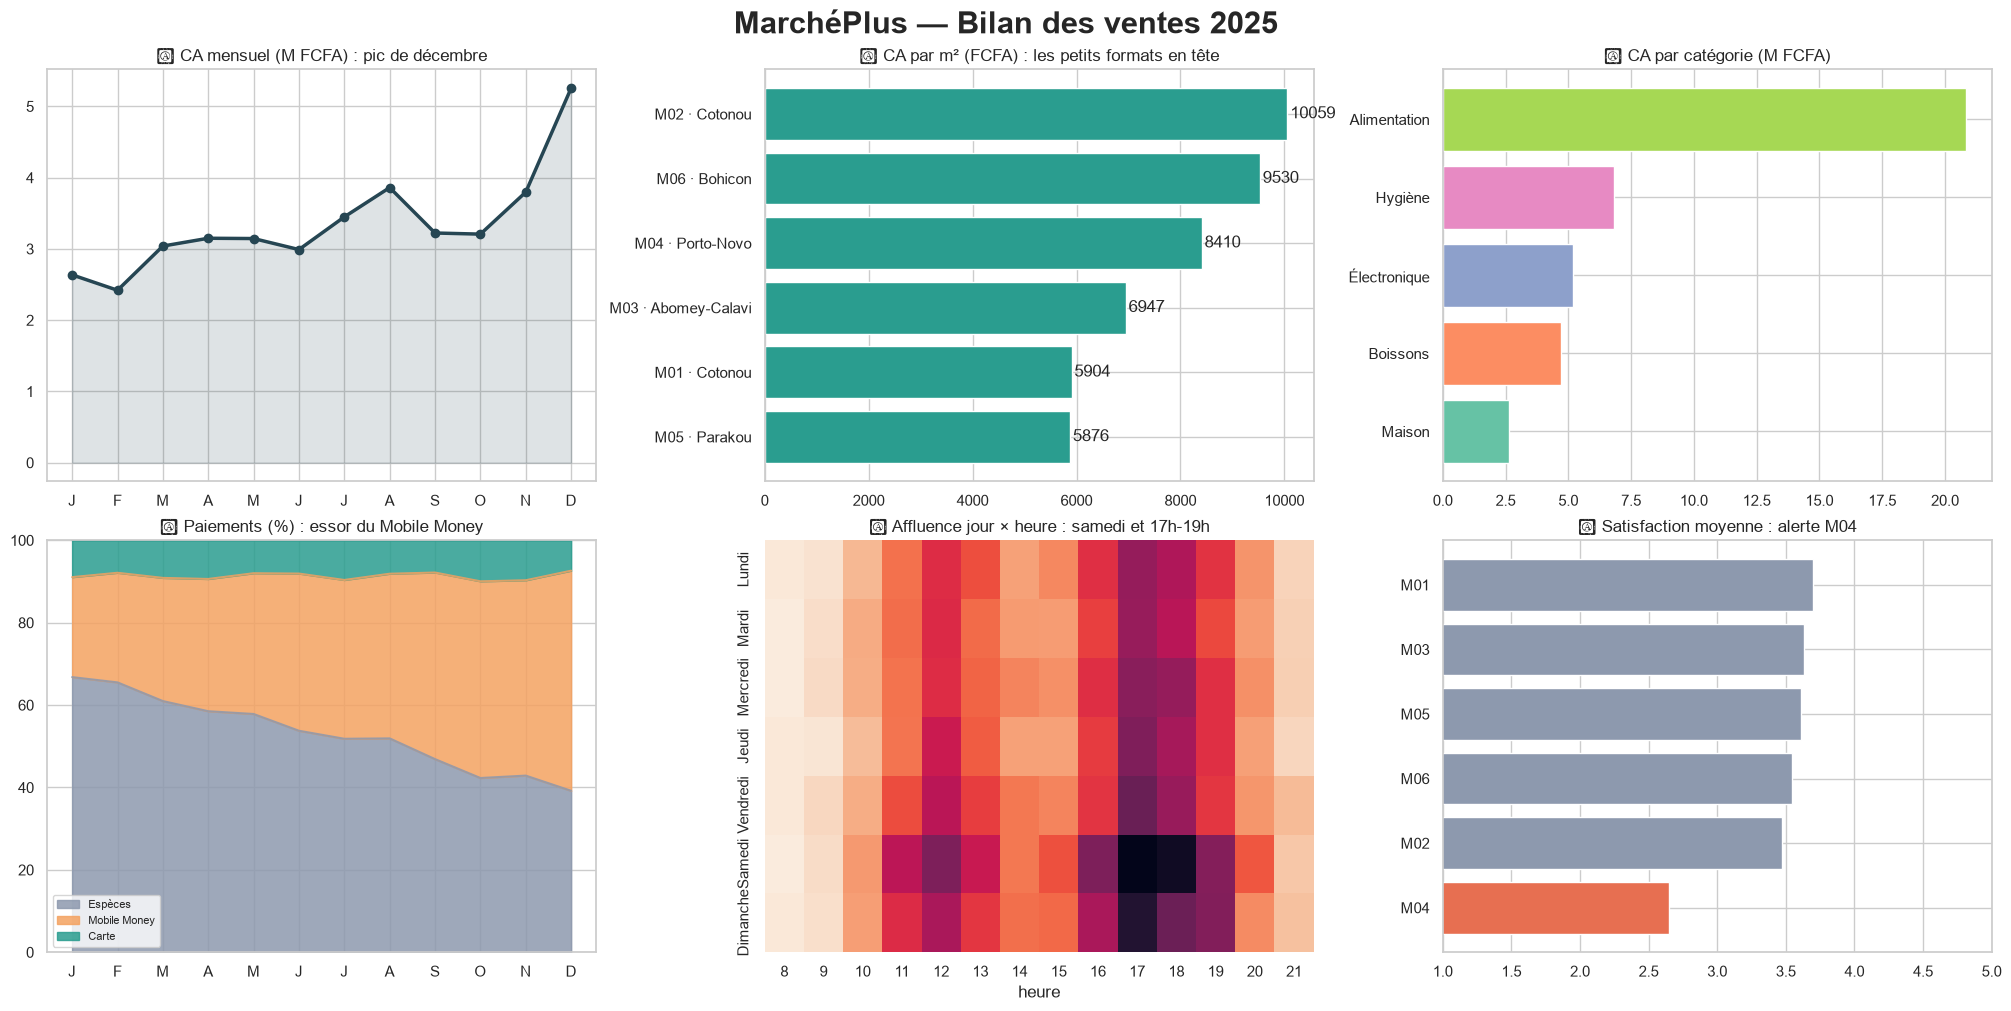

In [162]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), layout="constrained")

ax = axes[0, 0]
ax.plot(mensuel.index, mensuel.values, marker="o", lw=2.5, color="#264653")
ax.fill_between(mensuel.index, mensuel.values, alpha=0.15, color="#264653")
ax.set_xticks(range(1, 13), [m[0] for m in MOIS]); ax.set_title("① CA mensuel (M FCFA) : pic de décembre")

ax = axes[0, 1]
d = perf.sort_values("ca_par_m2")
ax.barh(d["magasin"], d["ca_par_m2"], color="#2a9d8f")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=2); ax.set_title("② CA par m² (FCFA) : les petits formats en tête")

ax = axes[0, 2]
cat_ca = df.groupby("categorie")["montant"].sum().sort_values() / 1e6
ax.barh(cat_ca.index, cat_ca.values, color=sns.color_palette("Set2", len(cat_ca)))
ax.set_title("③ CA par catégorie (M FCFA)")

ax = axes[1, 0]
parts_mois.plot.area(ax=ax, color=couleurs, alpha=0.85)
ax.set_xticks(range(1, 13), [m[0] for m in MOIS]); ax.set_ylim(0, 100); ax.set_xlabel("")
ax.legend(loc="lower left", fontsize=8); ax.set_title("④ Paiements (%) : essor du Mobile Money")

ax = axes[1, 1]
sns.heatmap(grille, cmap="rocket_r", cbar=False, ax=ax)
ax.set_title("⑤ Affluence jour × heure : samedi et 17h-19h"); ax.set_ylabel("")

ax = axes[1, 2]
s = df.groupby("id_magasin")["satisfaction"].mean().sort_values()
ax.barh(s.index, s.values, color=["#e76f51" if x < 3.2 else "#8d99ae" for x in s.values])
ax.set_xlim(1, 5); ax.set_title("⑥ Satisfaction moyenne : alerte M04")

fig.suptitle("MarchéPlus — Bilan des ventes 2025", fontsize=22, fontweight="bold")
fig.savefig("figures/tableau_de_bord_marcheplus.png", dpi=200, bbox_inches="tight")
plt.show()

---
# 📌 Aide-mémoire

| NumPy | Pandas | Matplotlib | Seaborn |
|---|---|---|---|
| `np.array`, `arange`, `linspace` | `pd.read_csv`, `DataFrame` | `fig, ax = plt.subplots()` | `sns.set_theme()` |
| `.shape`, `.reshape`, `.dtype` | `head`, `info`, `describe` | `ax.plot`, `ax.scatter` | `histplot`, `kdeplot` |
| `X[i, j]`, `X[X > 0]`, `np.where` | `loc`, `iloc`, filtres `& \| ~` | `ax.bar`, `ax.barh`, `bar_label` | `boxplot`, `violinplot`, `stripplot` |
| `+ - * /` vectorisés, broadcasting | `isna`, `fillna`, `drop_duplicates` | `ax.hist`, `ax.boxplot`, `ax.pie` | `countplot`, `barplot` |
| `sum/mean/std(axis=…)` | `.str`, `.dt`, `pd.cut` | `ax.set_title/xlabel/ylabel`, `legend` | `scatterplot`, `regplot` |
| `np.nanmean` | `groupby().agg()`, `crosstab` | `plt.subplots(n, m)` | `heatmap` |
| `rng = default_rng(seed)` | `merge` | `ax.annotate`, `axhline`, `fig.savefig` | `pairplot`, `jointplot`, `lmplot` |


Documentation officielle : [numpy.org](https://numpy.org/doc/) · [pandas.pydata.org](https://pandas.pydata.org/docs/) ·
[matplotlib.org](https://matplotlib.org/stable/gallery/) (galerie !) · [seaborn.pydata.org](https://seaborn.pydata.org/examples/)